# Наблюдаемость LLM-приложения в Langfuse

## Трассировка, версионирование промптов, A/B-тестирование и оценка качества

Работа выполнена в рамках практического задания курса по работе с LLM (практика 1, Langfuse) и включает пять заданий:

1. базовое подключение Langfuse и трассировка запросов;
2. версионирование промптов (Prompt Management);
3. A/B-тестирование промптов;
4. эксперименты с параметрами модели и их трассировка;
5. собственный кейс LLM-приложения и конвейер оценки качества (dataset, experiment, метрики).

**Инфраструктура.** Используется облачная версия Langfuse (Langfuse Cloud, регион EU, тариф Hobby).

* Приложение в заданиях 1–4 — генератор карточек товаров для маркетплейса, в задании 5 — ассистент службы поддержки интернет-магазина.
* Модель-генератор — `GigaChat-2` (тариф Freemium), вызывается через LangChain. Трассировку выполняет обработчик `langfuse.langchain.CallbackHandler`.
* Модель-оценщик (LLM-as-a-Judge) — `deepseek-flash` (DeepSeek API); она не зависит от генератора.

**Воспроизводимость.** Трейсы записаны в окружение `homework` проекта Langfuse. В каталоге `results/` сохранены результаты каждого эксперимента (идентификаторы трейсов, ответы, измерения) и данные, полученные из API Langfuse. Повторный запуск ноутбука не создаёт новых трейсов и воспроизводит приведённые результаты; чтобы провести эксперименты заново, нужно установить `RERUN = True`. Ссылки на публичные трейсы приведены в п. 1.3.

**Запуск.**

1. Установить зависимости: `pip install -r requirements.txt`.
2. Указать ключи в файле `.env` (шаблон — `.env.example`): `LANGFUSE_PUBLIC_KEY`, `LANGFUSE_SECRET_KEY`, `LANGFUSE_HOST`, `GIGACHAT_CREDENTIALS` и, при необходимости, `DEEPSEEK_API_KEY`.
3. Сертификат Минцифры для проверки SSL GigaChat — `certs/russian_trusted_root_ca.pem`.

## 0. Подготовка окружения

In [1]:
# Зависимости (один раз): %pip install langfuse langchain langchain-gigachat langchain-openai pandas scipy matplotlib python-dotenv
import os, re, json, math, time, random, itertools
from collections import Counter
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

load_dotenv(".env")  # ключи берутся из файла .env в рабочей папке
os.environ.setdefault("LANGFUSE_TRACING_ENVIRONMENT", "homework")

from langfuse import get_client, propagate_attributes, Evaluation
from langfuse.langchain import CallbackHandler
from langchain_core.prompts import ChatPromptTemplate
from langchain_gigachat import GigaChat
from langchain_openai import ChatOpenAI

pd.set_option("display.max_colwidth", 120)
langfuse = get_client()
print("Подключение к Langfuse:", langfuse.auth_check(), "| окружение:", os.environ["LANGFUSE_TRACING_ENVIRONMENT"])

Подключение к Langfuse: True | окружение: homework


Вспомогательные функции:

* `gigachat` — модель-генератор `GigaChat` через LangChain;
* `judge_llm` — модель-оценщик: `deepseek-flash` (DeepSeek API) либо, при отсутствии ключа, `GigaChat-2-Max`;
* `run_traced` — один вызов приложения в отдельном трейсе Langfuse с атрибутами `user_id`, `session_id`, тегами и metadata. Функция возвращает ответ и измерения: время, токены, модель, идентификатор трейса;
* `stored` — сохранение результатов эксперимента в `results/`: повторный запуск ноутбука не создаёт новых трейсов.

In [2]:
SUFFIX = os.getenv("PRACTICE_SUFFIX", "")            # пусто — основной запуск; "-dev" — отладочный
RESULTS = Path(os.getenv("RESULTS_DIR", "results"))
RESULTS.mkdir(parents=True, exist_ok=True)
RERUN = False  # True — провести эксперименты заново (будут созданы новые трейсы)

CA_BUNDLE = Path("certs/russian_trusted_root_ca.pem")  # корневой сертификат Минцифры для SSL GigaChat


def gigachat(model="GigaChat-2", **params):
    ssl = {"ca_bundle_file": str(CA_BUNDLE)} if CA_BUNDLE.exists() else {"verify_ssl_certs": False}
    return GigaChat(model=model, timeout=180, **ssl, **params)


def judge_llm():
    if os.getenv("DEEPSEEK_API_KEY"):
        return ChatOpenAI(model="deepseek-flash", base_url="https://api.deepseek.com",
                          api_key=os.environ["DEEPSEEK_API_KEY"], temperature=0, max_tokens=500), "deepseek-flash"
    return gigachat("GigaChat-2-Max", temperature=0.01, max_tokens=500), "GigaChat-2-Max"


JUDGE, JUDGE_NAME = judge_llm()


def stored(name, run):
    """Результат эксперимента: из файла, если эксперимент уже проводился, иначе — выполнить и сохранить."""
    path = RESULTS / f"{name}.json"
    if path.exists() and not RERUN:
        return json.loads(path.read_text("utf-8"))
    data = run()
    path.write_text(json.dumps(data, ensure_ascii=False, indent=1, default=str), "utf-8")
    return data


def run_traced(chain, inputs, *, trace_name, user_id=None, session_id=None, tags=(), metadata=None,
               prompt=None, public=False):
    """Один вызов LLM-приложения в отдельном трейсе Langfuse."""
    handler = CallbackHandler()
    started_at = datetime.now(timezone.utc).isoformat()
    with langfuse.start_as_current_observation(as_type="span", name=trace_name, input=inputs) as span:
        with propagate_attributes(trace_name=trace_name, user_id=user_id, session_id=session_id,
                                  tags=list(tags), metadata=metadata or {}, prompt=prompt):
            t0 = time.perf_counter()
            msg = chain.invoke(inputs, config={"callbacks": [handler]})
            latency = time.perf_counter() - t0
            span.update(output=msg.content)
            if public:
                langfuse.set_current_trace_as_public()
            trace_id = langfuse.get_current_trace_id()
    usage = msg.usage_metadata or {}
    return {"trace_id": trace_id, "started_at": started_at, "output": msg.content, "latency_s": round(latency, 3),
            "input_tokens": usage.get("input_tokens"), "output_tokens": usage.get("output_tokens"),
            "model": msg.response_metadata.get("model_name"), "finish_reason": msg.response_metadata.get("finish_reason")}


def words(text):
    return len(re.findall(r"\w+", text or ""))


WORD_RE = re.compile(r"[а-яёa-z]{3,}")


def similarity(a, b):
    """Лексическая близость двух текстов: косинус векторов частот слов (0..1)."""
    wa, wb = Counter(WORD_RE.findall(a.lower())), Counter(WORD_RE.findall(b.lower()))
    dot = sum(wa[w] * wb[w] for w in wa)
    norm = math.sqrt(sum(v * v for v in wa.values())) * math.sqrt(sum(v * v for v in wb.values()))
    return dot / norm if norm else 0.0


def mean_pairwise_similarity(texts):
    pairs = list(itertools.combinations(texts, 2))
    return sum(similarity(a, b) for a, b in pairs) / len(pairs) if pairs else float("nan")


def parse_json_object(text):
    """Первый JSON-объект в тексте (модели иногда обрамляют JSON блоком ```json)."""
    m = re.search(r"\{.*\}", text or "", re.S)
    return json.loads(m.group(0)) if m else None


def ask_judge(prompt_text, *, tags, metadata=None):
    """Вызов модели-оценщика (отдельный трейс с тегом judge). Возвращает разобранный JSON-ответ."""
    chain = ChatPromptTemplate.from_messages([("user", "{p}")]) | JUDGE
    for attempt in range(2):
        r = run_traced(chain, {"p": prompt_text}, trace_name="judge", user_id="judge", tags=["practice1", "judge", *tags],
                       metadata={"judge_model": JUDGE_NAME, **(metadata or {})})
        try:
            data = parse_json_object(r["output"])
            if data is not None:
                return data, r["trace_id"]
        except json.JSONDecodeError:
            pass
    return None, r["trace_id"]


OBS_FIELDS = "basic,model,usage,prompt,metrics,trace_context"


def fetch_traces(runs, attempts=12, pause=10):
    """Данные трейсов из Langfuse (API наблюдений v2): длительность, модель, параметры, токены, версия промпта,
    атрибуты трейса и структура вызова. Данные доступны после асинхронной обработки на сервере, поэтому
    функция повторяет запрос, пока трейсы не будут обработаны.

    Учёт входных токенов. GigaChat возвращает в prompt_tokens только незакэшированную часть промпта, а
    закэшированную — отдельно. Интеграция LangChain → Langfuse вычитает кэш из prompt_tokens, и поле input
    в Langfuse обнуляется. Поэтому полный размер промпта восстанавливается как (total − output) + input_cache_read."""
    langfuse.flush()
    pending = {r["trace_id"]: datetime.fromisoformat(r["started_at"]) for r in runs}
    out = {}
    for _ in range(attempts):
        for tid, t0 in list(pending.items()):
            obs = langfuse.api.observations.get_many(trace_id=tid, fields=OBS_FIELDS, limit=100,
                                                     from_start_time=t0 - timedelta(minutes=5),
                                                     to_start_time=t0 + timedelta(hours=1)).data
            gens = [o for o in obs if o.type == "GENERATION"]
            root = next((o for o in obs if o.is_root_observation), None)
            if not gens or root is None or not (gens[0].usage_details or {}):
                continue
            g = gens[0]
            u = g.usage_details or {}
            cached = u.get("input_cache_read", 0) or 0
            prompt_tokens = (u.get("total", 0) or 0) - (u.get("output", 0) or 0) + cached
            out[tid] = {
                "trace_id": tid, "trace_name": root.trace_name, "tags": root.tags, "user_id": root.user_id,
                "session_id": root.session_id, "environment": root.environment, "public": root.public,
                "trace_latency_s": root.latency, "generation_latency_s": g.latency, "model": g.model,
                "model_parameters": g.model_parameters, "prompt_name": g.prompt_name or None,
                "prompt_version": g.prompt_version, "input_tokens": prompt_tokens, "cached_input_tokens": cached,
                "output_tokens": u.get("output"), "total_tokens": prompt_tokens + (u.get("output", 0) or 0),
                "observations": [{"id": o.id, "parent": o.parent_observation_id, "type": o.type, "name": o.name,
                                  "start": o.start_time.isoformat(), "latency_s": o.latency or 0.0} for o in obs],
            }
            del pending[tid]
        if not pending:
            break
        time.sleep(pause)
    return [out[r["trace_id"]] for r in runs if r["trace_id"] in out]


def print_tree(observations):
    """Структура вызова: дерево наблюдений трейса."""
    children = {}
    for o in sorted(observations, key=lambda o: o.get("start", "")):
        children.setdefault(o["parent"], []).append(o)
    ids = {o["id"] for o in observations}
    roots = [o for o in observations if o["parent"] not in ids]

    def walk(o, depth):
        print("    " * depth + f"└─ {o['type']}: {o['name']} ({(o['latency_s'] or 0):.3f} с)")
        for c in children.get(o["id"], []):
            walk(c, depth + 1)
    for r in roots:
        walk(r, 0)


def trace_url(trace_id):
    return langfuse.get_trace_url(trace_id=trace_id)

---
## Задание 1. Базовое подключение Langfuse и трассировка запросов

**Развёртывание.** Используется облачная версия Langfuse (Langfuse Cloud, регион EU, тариф Hobby). SDK `langfuse` подключён через переменные окружения `LANGFUSE_PUBLIC_KEY`, `LANGFUSE_SECRET_KEY` и `LANGFUSE_HOST`. Трейсы записываются в окружение `homework`.

**Приложение** — генератор карточек товаров для маркетплейса: цепочка LangChain «шаблон промпта → `GigaChat-2`». Каждый запрос выполняется в отдельном трейсе:

* корневой span `product-card` содержит вход (описание товара) и выход (карточку);
* обработчик `CallbackHandler` автоматически записывает вложенные наблюдения: цепочку, шаблон промпта и генерацию с полным промптом, ответом модели, названием модели, параметрами генерации, числом токенов и временем выполнения;
* через `propagate_attributes` трейсу назначаются `user_id`, `session_id`, теги и metadata.

**План запросов.** 10 запросов по 10 различным товарам:

* теги: `baseline` (запросы 1–4, `temperature=0.3`), `test` (5–7, те же параметры), `experiment1` (8–10, `temperature=0.8`);
* три условных пользователя (`user-001` … `user-003`) и две сессии (`task1-session-1`, `task1-session-2`);
* первые два трейса сделаны публичными, чтобы их можно было открыть без авторизации в Langfuse.

In [3]:
PRODUCTS = [
    "Беспроводные наушники с активным шумоподавлением для тренировок, влагозащита IPX5, до 24 часов работы с кейсом",
    "Термокружка из нержавеющей стали, 450 мл, держит тепло 8 часов, герметичная крышка",
    "Детский альбом для рисования формата А4, 40 листов плотной бумаги 160 г/м²",
    "Набор свечей ручной работы из соевого воска: 3 аромата, время горения 30 часов",
    "Складной электросамокат для города: запас хода 25 км, вес 12 кг",
    "Шампунь без сульфатов для окрашенных волос, 250 мл",
    "Коврик для йоги из TPE толщиной 6 мм, нескользящий, с ремнём для переноски",
    "Настольная светодиодная лампа с регулировкой яркости и цветовой температуры, USB-порт для зарядки",
    "Рюкзак для ноутбука 15,6 дюйма: водоотталкивающая ткань, скрытый карман для документов",
    "Электрическая зубная щётка: 3 режима чистки, таймер на 2 минуты",
]

CARD_SYSTEM = (
    "Ты — маркетолог и контент-редактор маркетплейсов (Ozon, Wildberries). Создай карточку товара по описанию.\n"
    "Разделы карточки: Название; Краткое описание (1–2 предложения); Полное описание (4–6 предложений); "
    "Преимущества (4 пункта); Характеристики (список «параметр: значение»); SEO-ключевые слова (через запятую).\n"
    "Используй только сведения из описания товара: не придумывай характеристики, которых в нём нет. "
    "Объём — не более 250 слов."
)
card_prompt = ChatPromptTemplate.from_messages([("system", CARD_SYSTEM), ("user", "Описание товара: {product}")])

T1_PLAN = []
for i, product in enumerate(PRODUCTS):
    tag = "baseline" if i < 4 else ("test" if i < 7 else "experiment1")
    T1_PLAN.append({"n": i + 1, "product": product, "tag": tag, "temperature": 0.8 if tag == "experiment1" else 0.3,
                    "user_id": f"user-{i % 3 + 1:03d}", "session_id": f"task1-session-{i // 5 + 1}", "public": i < 2})


def task1():
    runs = []
    for p in T1_PLAN:
        chain = card_prompt | gigachat(temperature=p["temperature"], max_tokens=800)
        r = run_traced(chain, {"product": p["product"]}, trace_name="product-card", user_id=p["user_id"],
                       session_id=p["session_id"], tags=["practice1", "task1", p["tag"]],
                       metadata={"task": "1", "variant": p["tag"], "temperature": p["temperature"]}, public=p["public"])
        runs.append({**p, **r})
    return runs


t1_runs = stored("task1_runs", task1)
t1_lf = stored("task1_langfuse", lambda: fetch_traces(t1_runs))
print(f"Запросов: {len(t1_runs)}, трейсов получено из Langfuse: {len(t1_lf)}")

Запросов: 10, трейсов получено из Langfuse: 10


### 1.1. Трейсы в Langfuse

Данные получены из API Langfuse (наблюдения v2), то есть это те же значения, что отображаются в интерфейсе (раздел Tracing). Длительность трейса — время корневого span, длительность генерации — время вызова модели.

In [4]:
lf_by_id = {t["trace_id"]: t for t in t1_lf}
rows = []
for r in t1_runs:
    t = lf_by_id[r["trace_id"]]
    rows.append({"№": r["n"], "тег": r["tag"], "user_id": t["user_id"], "session_id": t["session_id"],
                 "trace, с": t["trace_latency_s"], "генерация, с": t["generation_latency_s"], "модель": t["model"],
                 "параметры": t["model_parameters"], "вход, токенов": t["input_tokens"],
                 "из них из кэша": t["cached_input_tokens"], "выход, токенов": t["output_tokens"]})
df_t1 = pd.DataFrame(rows).set_index("№")
df_t1

,тег,user_id,session_id,"trace, с","генерация, с",модель,параметры,"вход, токенов",из них из кэша,"выход, токенов"
№,,,,,,,,,,
1,baseline,user-001,task1-session-1,3.670,3.668,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",170,109,328
2,baseline,user-002,task1-session-1,2.866,2.865,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",162,109,263
3,baseline,user-003,task1-session-1,2.756,2.753,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",162,109,259
4,baseline,user-001,task1-session-1,2.965,2.961,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",161,0,299
5,test,user-002,task1-session-1,3.062,3.059,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",160,109,298
6,test,user-003,task1-session-2,2.992,2.991,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",155,109,244
7,test,user-001,task1-session-2,3.178,3.175,GigaChat-2:2.0.30.01,"{'temperature': 0.3, 'max_tokens': 800}",162,109,300
8,experiment1,user-002,task1-session-2,3.189,3.187,GigaChat-2:2.0.30.01,"{'temperature': 0.8, 'max_tokens': 800}",158,109,298
9,experiment1,user-003,task1-session-2,2.813,2.810,GigaChat-2:2.0.30.01,"{'temperature': 0.8, 'max_tokens': 800}",162,109,276


In [5]:
agg = df_t1.groupby("тег", sort=False).agg(**{"запросов": ("trace, с", "count"), "длительность, с (среднее)": ("trace, с", "mean"),
                                             "мин": ("trace, с", "min"), "макс": ("trace, с", "max"),
                                             "вход, токенов": ("вход, токенов", "mean"), "выход, токенов": ("выход, токенов", "mean")}).round(2)
agg

,запросов,"длительность, с (среднее)",мин,макс,"вход, токенов","выход, токенов"
тег,,,,,,
baseline,4,3.06,2.76,3.67,163.75,287.25
test,3,3.08,2.99,3.18,159.00,280.67
experiment1,3,2.96,2.81,3.19,159.33,283.00


### 1.2. Структура вызова

Дерево наблюдений одного трейса: корневой span приложения, цепочка LangChain (`RunnableSequence`), шаблон промпта и генерация модели. В скобках указана длительность каждого наблюдения.

In [6]:
print_tree(t1_lf[0]["observations"])
print("\nДоля времени генерации в длительности трейса:",
      f"{(df_t1['генерация, с'] / df_t1['trace, с']).mean():.1%} (среднее по 10 трейсам)")

└─ SPAN: product-card (3.670 с)
    └─ CHAIN: RunnableSequence (3.668 с)
        └─ GENERATION: GigaChat (3.668 с)
        └─ CHAIN: ChatPromptTemplate (0.000 с)

Доля времени генерации в длительности трейса: 99.9% (среднее по 10 трейсам)


### 1.3. Публичные трейсы и пример ответа

Публичные трейсы открываются по ссылке без авторизации; в них видны промпт, ответ модели, модель, параметры, токены и время выполнения.

In [7]:
for r in t1_runs:
    if r["public"]:
        print(f"Трейс {r['n']} ({r['tag']}): {trace_url(r['trace_id'])}")
print("\nОтвет модели (трейс 1):\n")
print(t1_runs[0]["output"])

Трейс 1 (baseline): https://cloud.langfuse.com/project/cmv0zn87700w1ad0gzxrqpptb/traces/c944f98b1098a44121b6d7a1f5f29e4b
Трейс 2 (baseline): https://cloud.langfuse.com/project/cmv0zn87700w1ad0gzxrqpptb/traces/255e9345314cbb0e8015b789cd590b3c

Ответ модели (трейс 1):

Название: Беспроводные наушники с активным шумоподавлением для тренировок

Краткое описание: Удобные беспроводные наушники с функцией активного шумоподавления, предназначенные для интенсивных тренировок и повседневной активности.

Полное описание: Эти наушники станут незаменимым помощником во время спортивных занятий благодаря активному шумоподавлению, которое эффективно устраняет внешние звуки, позволяя сосредоточиться на тренировке. Благодаря влагозащите стандарта IPX5 вы можете не беспокоиться об использовании устройства под дождем или во влажном помещении. Длительное время автономной работы – до 24 часов вместе с зарядным кейсом – обеспечивает свободу передвижения и комфорт даже в длительных поездках.

Преимущества:
1.

### Выводы по заданию 1

**Что фиксирует трассировка.** Для каждого из 10 запросов Langfuse записал трейс со следующими данными:

* полный промпт (системное и пользовательское сообщения) и ответ модели;
* модель с точной версией (`GigaChat-2:2.0.30.01`) и параметры генерации (`temperature`, `max_tokens`);
* число входных и выходных токенов;
* длительность каждого наблюдения;
* атрибуты трейса: `user_id`, `session_id`, теги (`baseline`, `test`, `experiment1`) и metadata.

**Результаты анализа.**

* **Длительность** — 2,76–3,67 с; в среднем 3,06 с (baseline), 3,08 с (test) и 2,96 с (experiment1). Различия между группами находятся в пределах естественного разброса: повышение температуры с 0,3 до 0,8 на время ответа заметно не повлияло.
* **Токены.** Промпт — 155–170 токенов; в 9 запросах из 10 его часть объёмом 109 токенов (системное сообщение) взята из кэша GigaChat. Ответ — 244–328 токенов, в среднем 281–287 по группам.
* **Структура вызова:** корневой span приложения → цепочка LangChain `RunnableSequence` → шаблон промпта (≈0 с) и генерация модели. На генерацию приходится 99,9% длительности трейса, накладные расходы приложения и трассировки пренебрежимо малы.

**Возможности трассировки.**

* Каждый вызов полностью воспроизводим: точный промпт, параметры и версия модели доступны для отладки.
* Длительность и потребление токенов можно анализировать в разрезе пользователей, сессий, тегов и версий.
* Окружения (`homework`, `development`) разделены, отдельные трейсы открываются по публичной ссылке.
* Интеграция с LangChain не требует изменения кода приложения: достаточно обработчика `CallbackHandler` и контекста `propagate_attributes`.

**Выявленные ограничения.**

* Данные становятся доступны через API с задержкой (асинхронная обработка на сервере), поэтому чтение результатов требует ожидания.
* Для организаций, созданных после 16.09.2026, устаревший API трейсов (`/api/public/traces`) недоступен; данные читаются через API наблюдений v2 и API метрик v2.
* Учёт токенов зависит от интеграции. GigaChat передаёт закэшированную часть промпта отдельно, и Langfuse обнуляет поле входных токенов, поэтому полный размер промпта пришлось восстанавливать вручную. Показатели наблюдаемости следует проверять на соответствие семантике конкретного провайдера.

---
## Задание 2. Версионирование промптов

**Постановка.** В Langfuse Prompt Management создаётся промпт `product-card` в трёх версиях. Версии помечаются метками `v1`, `v2`, `v3`; вместе с текстом хранится конфигурация модели (`model`, `temperature`, `max_tokens`):

* **v1** — базовая инструкция: одно сообщение пользователя «составь карточку товара»;
* **v2** — улучшенная инструкция: перечень обязательных разделов, ограничение объёма, запрет придумывать характеристики;
* **v3** — изменённая структура: требования вынесены в системное сообщение (system role), а сообщение пользователя содержит только описание товара; добавлено требование к стилю и оформлению заголовков.

Промпты загружаются через API Langfuse (`get_prompt` по метке) и преобразуются в шаблон LangChain. Каждая генерация связывается с версией промпта (`propagate_attributes(prompt=...)`), поэтому Langfuse рассчитывает метрики отдельно по каждой версии. Каждая версия тестируется на одних и тех же 5 задачах (товарах) с двумя повторами — всего 30 генераций.

**Показатели:**

* **качество** — средняя из трёх оценок модели-оценщика по шкале 1–5: полнота, достоверность (отсутствие придуманных характеристик), убедительность; дополнительно кодом проверяется наличие всех шести разделов (`format_ok`). Оценки записываются в трейсы как scores;
* **длина ответа** (слов), **время генерации**, **количество токенов**;
* **стабильность** — разброс показателей между задачами и повторами.

In [8]:
PROMPT_NAME = "product-card" + SUFFIX
PROMPT_CONFIG = {"model": "GigaChat-2", "temperature": 0.3, "max_tokens": 800}
CARD_RULES = (
    "Карточка должна содержать разделы: Название; Краткое описание (1–2 предложения); Полное описание "
    "(4–6 предложений); Преимущества (4 пункта); Характеристики (список «параметр: значение»); "
    "SEO-ключевые слова (через запятую).\n"
    "Используй только сведения из описания товара, не придумывай характеристики. Объём — не более 250 слов."
)
PROMPT_VERSIONS = {
    "v1": ([{"role": "user", "content": "Составь карточку товара для маркетплейса.\n\nТовар: {{product}}"}],
           "v1: базовая инструкция"),
    "v2": ([{"role": "user", "content": "Составь карточку товара для маркетплейса (Ozon, Wildberries).\n" + CARD_RULES
             + "\n\nТовар: {{product}}"}],
           "v2: обязательные разделы, ограничение объёма, запрет придумывать характеристики"),
    "v3": ([{"role": "system", "content": "Ты — маркетолог и контент-редактор маркетплейсов (Ozon, Wildberries).\n" + CARD_RULES
             + "\nСтиль — информативный и продающий, с упором на выгоду для покупателя. "
               "Каждый раздел начинай с заголовка вида **Название раздела:**."},
            {"role": "user", "content": "Товар: {{product}}"}],
           "v3: системная роль и отдельное сообщение пользователя"),
}


def ensure_prompt(name, label, messages, commit_message):
    """Версия промпта с заданной меткой; создаётся, если её ещё нет (повторный запуск не плодит версии)."""
    try:
        return langfuse.get_prompt(name, label=label, type="chat", cache_ttl_seconds=0, max_retries=0)
    except Exception:
        langfuse.create_prompt(name=name, type="chat", prompt=messages, labels=[label], config=PROMPT_CONFIG,
                               commit_message=commit_message)
        return langfuse.get_prompt(name, label=label, type="chat", cache_ttl_seconds=0)


prompts = {label: ensure_prompt(PROMPT_NAME, label, msgs, msg) for label, (msgs, msg) in PROMPT_VERSIONS.items()}
for label, pr in prompts.items():
    print(f"{label}: версия {pr.version}, метки {pr.labels}, config {pr.config}")

v1: версия 1, метки ['v1'], config {'model': 'GigaChat-2', 'temperature': 0.3, 'max_tokens': 800}
v2: версия 2, метки ['v2'], config {'model': 'GigaChat-2', 'temperature': 0.3, 'max_tokens': 800}
v3: версия 3, метки ['v3', 'latest'], config {'model': 'GigaChat-2', 'temperature': 0.3, 'max_tokens': 800}


In [9]:
T2_PRODUCTS = [PRODUCTS[i] for i in (0, 1, 4, 5, 8)]  # 5 одинаковых задач для всех версий


def llm_from_config(config):
    return gigachat(config["model"], temperature=config["temperature"], max_tokens=config["max_tokens"])


def task2():
    runs = []
    for label, pr in prompts.items():
        chain = ChatPromptTemplate.from_messages(pr.get_langchain_prompt()) | llm_from_config(pr.config)
        for pid, product in enumerate(T2_PRODUCTS):
            for rep in range(2):
                r = run_traced(chain, {"product": product}, trace_name="product-card", user_id="tester",
                               session_id=f"task2-{label}", tags=["practice1", "task2", f"prompt-{label}"],
                               metadata={"task": "2", "prompt_label": label, "product_id": pid, "repeat": rep}, prompt=pr)
                runs.append({"label": label, "prompt_version": pr.version, "product_id": pid, "repeat": rep,
                             "product": product, **r})
    return runs


t2_runs = stored("task2_runs", task2)
print("Генераций:", len(t2_runs))

Генераций: 30


### 2.1. Оценка качества

Проверка формата выполняется кодом: в ответе ищутся все шесть разделов. Модель-оценщик получает описание товара и карточку и возвращает три оценки по шкале 1–5 в формате JSON. Каждая оценка выполняется отдельным трейсом с тегом `judge`, а результаты записываются как scores в трейс соответствующей генерации.

In [10]:
SECTIONS = {"название": r"назван", "краткое описание": r"кратк\w* описан", "полное описание": r"полн\w* описан",
            "преимущества": r"преимущ", "характеристики": r"характеристик", "seo": r"seo|ключев\w* слов"}


def sections_found(text):
    """Разделы карточки: строка начинается с названия раздела (символы разметки в начале строки отбрасываются)."""
    starts = [re.sub(r"^[\W_]+", "", line).lower() for line in (text or "").splitlines() if line.strip()]
    return [s for s, rx in SECTIONS.items() if any(re.match(rx, line) for line in starts)]


JUDGE_CARD = """Ты — независимый эксперт по контенту маркетплейсов. Оцени карточку товара по трём критериям по шкале от 1 до 5:
- completeness — полнота: есть ли название, краткое и полное описание, преимущества, характеристики и SEO-ключевые слова;
- faithfulness — достоверность: все характеристики и утверждения следуют из описания товара; за каждую придуманную характеристику оценка снижается;
- persuasiveness — убедительность и ясность текста для покупателя.

Описание товара: {product}

Карточка товара:
<<<
{card}
>>>

Верни только JSON: {{"completeness": число, "faithfulness": число, "persuasiveness": число, "comment": "краткое пояснение на русском"}}"""


def judge_card(product, card, tags):
    data, judge_trace = ask_judge(JUDGE_CARD.format(product=product, card=card), tags=tags)
    keys = ["completeness", "faithfulness", "persuasiveness"]
    if not data or not all(isinstance(data.get(k), (int, float)) for k in keys):
        return None
    return {**{k: float(data[k]) for k in keys}, "quality": round(sum(float(data[k]) for k in keys) / 3, 2),
            "comment": str(data.get("comment", ""))[:500], "judge_trace_id": judge_trace}


def task2_eval():
    out = []
    for r in t2_runs:
        found = sections_found(r["output"])
        j = judge_card(r["product"], r["output"], tags=["task2"])
        langfuse.create_score(trace_id=r["trace_id"], name="format_ok", value=int(len(found) == len(SECTIONS)),
                              data_type="BOOLEAN", comment=f"найдено разделов: {len(found)}/{len(SECTIONS)}")
        if j:
            langfuse.create_score(trace_id=r["trace_id"], name="quality", value=j["quality"], data_type="NUMERIC",
                                  comment=j["comment"])
            langfuse.create_score(trace_id=r["trace_id"], name="faithfulness", value=j["faithfulness"], data_type="NUMERIC")
        out.append({"trace_id": r["trace_id"], "sections": len(found), **(j or {})})
    langfuse.flush()
    return out


t2_eval = stored("task2_eval", task2_eval)
print("Оценено генераций:", sum("quality" in e for e in t2_eval), "из", len(t2_eval))

Оценено генераций: 30 из 30


### 2.2. Сравнение версий

In [11]:
t2_lf = stored("task2_langfuse", lambda: fetch_traces(t2_runs))
lf2 = {t["trace_id"]: t for t in t2_lf}
ev2 = {e["trace_id"]: e for e in t2_eval}
df_t2 = pd.DataFrame([{
    "версия": r["label"], "товар": r["product_id"], "повтор": r["repeat"], "слов": words(r["output"]),
    "генерация, с": lf2[r["trace_id"]]["generation_latency_s"], "вход, токенов": lf2[r["trace_id"]]["input_tokens"],
    "выход, токенов": lf2[r["trace_id"]]["output_tokens"], "разделов": ev2[r["trace_id"]]["sections"],
    "format_ok": ev2[r["trace_id"]]["sections"] == len(SECTIONS), "quality": ev2[r["trace_id"]].get("quality"),
    "faithfulness": ev2[r["trace_id"]].get("faithfulness"), "output": r["output"]} for r in t2_runs])


def summary_by_version(df):
    g = df.groupby("версия")
    rep_sim = {v: sum(similarity(*grp.sort_values("повтор")["output"].tolist()) for _, grp in d.groupby("товар")) / d["товар"].nunique()
               for v, d in df.groupby("версия")}
    return pd.DataFrame({
        "format_ok": g["format_ok"].mean().map("{:.0%}".format),
        "quality (среднее)": g["quality"].mean().round(2), "quality (СКО)": g["quality"].std().round(2),
        "faithfulness": g["faithfulness"].mean().round(2),
        "слов (среднее)": g["слов"].mean().round(0), "слов (CV)": (g["слов"].std() / g["слов"].mean()).round(2),
        "генерация, с": g["генерация, с"].mean().round(2), "вход, токенов": g["вход, токенов"].mean().round(0),
        "выход, токенов": g["выход, токенов"].mean().round(0),
        "сходство повторов": pd.Series(rep_sim).round(2),
    })


summary_by_version(df_t2)

,format_ok,quality (среднее),quality (СКО),faithfulness,слов (среднее),слов (CV),"генерация, с","вход, токенов","выход, токенов",сходство повторов
v1,0%,3.33,0.32,1.2,218.0,0.16,3.22,55.0,465.0,0.49
v2,100%,3.63,0.37,1.5,167.0,0.08,2.52,146.0,336.0,0.81
v3,80%,3.74,0.26,2.0,154.0,0.11,2.54,183.0,306.0,0.77


**Сравнение в Langfuse.** Те же показатели рассчитаны средствами Langfuse через API метрик v2: средняя длительность генерации и число выходных токенов по версиям промпта (группировка `promptVersion`) и средние оценки по тегам версий. В интерфейсе эти данные доступны в разделе Prompts → `product-card` → Metrics и на дашбордах. Входные токены здесь не приводятся: для GigaChat они учитываются в Langfuse не полностью из-за кэширования промпта (см. пояснение к функции `fetch_traces`). Скорректированные значения приведены в таблице выше.

In [12]:
def lf_metrics(view, dimensions, measures, filters=(), since=None, until=None):
    query = {"view": view, "dimensions": [{"field": d} for d in dimensions],
             "metrics": [{"measure": m, "aggregation": a} for m, a in measures],
             "filters": [{"column": "environment", "operator": "=", "value": os.environ["LANGFUSE_TRACING_ENVIRONMENT"],
                          "type": "string"}, *filters],
             "fromTimestamp": since, "toTimestamp": until}
    return langfuse.api.metrics.metrics(query=json.dumps(query)).data


def run_window(runs, margin_min=30):
    ts = [datetime.fromisoformat(r["started_at"]) for r in runs]
    return (min(ts) - timedelta(minutes=margin_min)).isoformat(), (max(ts) + timedelta(hours=2)).isoformat()


def task2_langfuse_metrics():
    since, until = run_window(t2_runs)
    obs = lf_metrics("observations", ["promptName", "promptVersion"],
                     [("count", "count"), ("latency", "avg"), ("inputTokens", "avg"), ("outputTokens", "avg")],
                     [{"column": "promptName", "operator": "=", "value": PROMPT_NAME, "type": "string"}], since, until)
    scores = lf_metrics("scores-numeric", ["name", "tags"], [("count", "count"), ("value", "avg")], [], since, until)
    return {"observations": obs, "scores": scores}


t2_metrics = stored("task2_langfuse_metrics", task2_langfuse_metrics)
m_obs = pd.DataFrame(t2_metrics["observations"]).sort_values("promptVersion")
m_obs["avg_latency"] = (m_obs["avg_latency"] / 1000).round(2)
m_obs = m_obs.rename(columns={"count_count": "генераций", "avg_latency": "генерация, с (Langfuse)",
                              "avg_outputTokens": "выход, токенов"})
display(m_obs[["promptName", "promptVersion", "генераций", "генерация, с (Langfuse)", "выход, токенов"]])
m_sc = pd.DataFrame(t2_metrics["scores"])
m_sc["версия"] = m_sc["tags"].map(lambda t: next((x.split("-")[1] for x in t if x.startswith("prompt-")), None))
display(m_sc.dropna(subset=["версия"]).pivot_table(index="версия", columns="name", values="avg_value").round(2))

,promptName,promptVersion,генераций,"генерация, с (Langfuse)","выход, токенов"
0,product-card,1,10,3.22,465.3
2,product-card,2,10,2.52,336.2
1,product-card,3,10,2.54,306.2


name,faithfulness,format_ok,quality
версия,,,
v1,1.2,0.0,3.33
v2,1.5,1.0,3.63
v3,2.0,0.8,3.74


### 2.3. Примеры ответов (товар 0, первый повтор)

In [13]:
for label in prompts:
    row = df_t2[(df_t2["версия"] == label) & (df_t2["товар"] == 0) & (df_t2["повтор"] == 0)].iloc[0]
    print(f"━━━ {label} · {row['слов']} слов · разделов {row['разделов']}/6 · quality {row['quality']}")
    print(row["output"].strip()[:1500], "\n")

━━━ v1 · 228 слов · разделов 1/6 · quality 3.67
## 🎧 Беспроводные наушники с активным шумоподавлением для тренировок  
🌟 **Особенности:**  
- Активное шумоподавление (ANC): комфорт тренировки даже в условиях городского шума  
- Влагозащита IPX5: устойчивы к поту и дождю, подходят для активного образа жизни  
- До 24 часов автономной работы + зарядный кейс: хватит на целый день тренировок  
- Удобный микрофон и управление касаниями: легко управлять музыкой прямо на ушах  
- Компактный чехол быстрой зарядки: быстро заряжайте наушники в дороге  

---

### 📌 Технические характеристики:
- Тип устройства: беспроводные наушники
- Шумоподавление: активное (ANC)
- Защита корпуса: IPX5
- Время работы от аккумулятора: до 8 часов (без кейса); до 24 часов вместе с кейсом
- Время полной зарядки кейса: около 1 часа
- Время подключения: менее 1 минуты
- Диапазон частот: 20 Гц – 20 кГц
- Чувствительность: ≥95 дБ
- Микрофон: встроенный с шумоподавлением
- Цвета: черный, белый, серый  

---

### 🛍️ Преим

### Выводы по заданию 2

| Показатель | v1 | v2 | v3 |
|---|---|---|---|
| соблюдение формата (6 разделов) | 0% | **100%** | 80% |
| качество, среднее (СКО) | 3,33 (0,32) | 3,63 (0,37) | **3,74 (0,26)** |
| достоверность (faithfulness) | 1,2 | 1,5 | **2,0** |
| длина, слов (коэффициент вариации) | 218 (0,16) | 167 (**0,08**) | 154 (0,11) |
| сходство повторов | 0,49 | **0,81** | 0,77 |
| время генерации, с | 3,22 | 2,52 | 2,54 |
| входных / выходных токенов | 55 / 465 | 146 / 336 | 183 / 306 |

* **v1 → v2 (улучшенная инструкция).** Явный перечень разделов и ограничения дали наибольший эффект:
  * формат соблюдается во всех ответах (0% → 100%);
  * длина ответа сократилась на 23%, выходные токены — на 28%, время генерации — на 22%;
  * разброс длины уменьшился вдвое (коэффициент вариации 0,16 → 0,08), сходство повторов выросло с 0,49 до 0,81;
  * качество выросло на 0,3 балла.
* **v2 → v3 (системная роль).** Перенос требований в системное сообщение и требование к стилю повысили качество до 3,74 и достоверность с 1,5 до 2,0, а ответ стал самым коротким (154 слова). Однако в двух ответах из десяти, оба для термокружки, отсутствовал раздел «Название»: модель начинала карточку сразу с названия товара без заголовка раздела.
* **Наиболее стабильная версия — v2**: 100% соблюдения формата, наименьший разброс длины и наибольшее сходство повторов. Наибольшее качество при наименьшем разбросе оценок показывает v3.
* **Достоверность остаётся низкой во всех версиях** (1,2–2,0 из 5). Несмотря на прямой запрет в v2 и v3, модель дополняет карточку характеристиками, которых нет в описании товара: вес, материал корпуса, ёмкость аккумулятора, цвета. Изменения промпта снижают, но не устраняют такие галлюцинации. Для их устранения модели нужно передавать полный набор характеристик товара в контексте и проверять ответ автоматически.
* **Влияние изменений в промпте.** Изменения инструкции влияют не только на качество, но и на стоимость и скорость. Более подробный промпт увеличивает число входных токенов (55 → 146 → 183), но сокращает ответ. В результате суммарное потребление токенов у v2 и v3 (482 и 489) на 6–7% ниже, чем у v1 (520), а время генерации — на 21–22% ниже. Версионирование в Langfuse позволяет сравнивать эти эффекты без изменения кода: версия выбирается по метке, а метрики автоматически группируются по `promptVersion`.

---
## Задание 3. A/B-тестирование промптов

**Постановка.** Для одной задачи (карточка товара) подготовлены два промпта, сохранённые в Langfuse Prompt Management как версии промпта `product-card-ab` с метками `variant-a` и `variant-b`:

* **A** — структурированная карточка: требования к разделам, объёму и достоверности, информативный стиль (аналог версии v3 из задания 2);
* **B** — продающая карточка по схеме AIDA (внимание → интерес → желание → действие) с акцентом на сценарии использования, при тех же требованиях к характеристикам, объёму и достоверности.

Для каждого из 40 запросов вариант выбирается случайно с вероятностью 0,5 (генератор `random.Random` с фиксированным зерном). Товары берутся по кругу из списка задания 1. В Langfuse для каждого запроса фиксируются:

* версия промпта — через связь генерации с промптом, тег `variant-a` / `variant-b` и metadata;
* время ответа и количество токенов — автоматически;
* пользовательская оценка по шкале 1–5 — score `user_rating`.

**Оговорка о пользовательской оценке.** Реальных пользователей в учебном эксперименте нет, поэтому оценка моделируется. Модель-оценщик выступает в роли покупателя, выбирающего товар, и отвечает, насколько карточка помогает принять решение о покупке. В рабочем приложении оценка поступала бы из интерфейса (например, звёзды или «полезно / бесполезно») через тот же вызов `create_score`.

In [14]:
AB_NAME = "product-card-ab" + SUFFIX
AB_PROMPTS = {
    "A": ([{"role": "system", "content": PROMPT_VERSIONS["v3"][0][0]["content"]},
           {"role": "user", "content": "Товар: {{product}}"}], "A: структурированная карточка"),
    "B": ([{"role": "system", "content":
            "Ты — копирайтер маркетплейса (Ozon, Wildberries). Напиши продающую карточку товара по схеме AIDA:\n"
            "1) Название и первая фраза привлекают внимание к главной выгоде;\n"
            "2) интерес — ключевые свойства товара;\n"
            "3) желание — сценарии использования и выгоды для покупателя;\n"
            "4) действие — короткий призыв к покупке.\n"
            "После текста приведи Характеристики (список «параметр: значение») и SEO-ключевые слова через запятую.\n"
            "Используй только сведения из описания товара, не придумывай характеристики. Объём — не более 250 слов."},
           {"role": "user", "content": "Товар: {{product}}"}], "B: продающая карточка по схеме AIDA"),
}
ab_prompts = {v: ensure_prompt(AB_NAME, f"variant-{v.lower()}", msgs, msg) for v, (msgs, msg) in AB_PROMPTS.items()}
for v, pr in ab_prompts.items():
    print(f"вариант {v}: версия {pr.version}, метки {pr.labels}")

N_AB = 40
rng = random.Random(20261009)
AB_PLAN = [{"k": k, "variant": "A" if rng.random() < 0.5 else "B", "product": PRODUCTS[k % len(PRODUCTS)]} for k in range(N_AB)]
print("Распределение вариантов:", Counter(p["variant"] for p in AB_PLAN))

вариант A: версия 1, метки ['variant-a']
вариант B: версия 2, метки ['variant-b', 'latest']
Распределение вариантов: Counter({'A': 21, 'B': 19})


In [15]:
USER_RATING_PROMPT = """Представь, что ты покупатель маркетплейса и выбираешь товар: {product}.
Перед тобой карточка этого товара:
<<<
{card}
>>>
Оцени по шкале от 1 до 5, насколько карточка помогает принять решение о покупке: понятно ли, что это за товар и чем он полезен, достаточно ли характеристик, вызывает ли текст доверие (нет ли преувеличений и придуманных свойств).
Верни только JSON: {{"rating": целое число от 1 до 5, "reason": "краткое пояснение на русском"}}"""


def task3():
    chains = {v: ChatPromptTemplate.from_messages(pr.get_langchain_prompt()) | llm_from_config(pr.config)
              for v, pr in ab_prompts.items()}
    runs = []
    for p in AB_PLAN:
        pr = ab_prompts[p["variant"]]
        r = run_traced(chains[p["variant"]], {"product": p["product"]}, trace_name="product-card",
                       user_id=f"customer-{p['k']:03d}", session_id="task3-ab-test",
                       tags=["practice1", "task3", "ab-test", f"variant-{p['variant'].lower()}"],
                       metadata={"task": "3", "variant": p["variant"], "prompt_version": pr.version}, prompt=pr)
        data, judge_trace = ask_judge(USER_RATING_PROMPT.format(product=p["product"], card=r["output"]), tags=["task3"])
        rating = data.get("rating") if data else None
        if isinstance(rating, (int, float)):
            langfuse.create_score(trace_id=r["trace_id"], name="user_rating", value=float(rating), data_type="NUMERIC",
                                  comment=str(data.get("reason", ""))[:500])
        runs.append({**p, **r, "user_rating": rating, "rating_reason": (data or {}).get("reason"), "judge_trace_id": judge_trace})
    langfuse.flush()
    return runs


t3_runs = stored("task3_runs", task3)
t3_lf = stored("task3_langfuse", lambda: fetch_traces(t3_runs))
lf3 = {t["trace_id"]: t for t in t3_lf}
df_t3 = pd.DataFrame([{"variant": r["variant"], "длительность, с": lf3[r["trace_id"]]["trace_latency_s"],
                       "токенов (всего)": lf3[r["trace_id"]]["total_tokens"], "выход, токенов": lf3[r["trace_id"]]["output_tokens"],
                       "слов": words(r["output"]), "user_rating": r["user_rating"]} for r in t3_runs])
print("Запросов:", len(df_t3), "| оценок получено:", df_t3["user_rating"].notna().sum())

Запросов: 40 | оценок получено: 40


### 3.1. Сравнение вариантов

Для времени ответа и числа токенов применяется t-критерий Уэлча (средние без предположения о равенстве дисперсий). Пользовательская оценка — порядковая шкала, поэтому для неё основным является U-критерий Манна — Уитни; t-критерий приводится справочно. Уровень значимости — 0,05.

In [16]:
from scipy import stats


def fmt_p(p):
    return f"{p:.4f}" if p >= 1e-4 else f"{p:.1e}"


desc = df_t3.groupby("variant").agg(**{"запросов": ("user_rating", "size"),
                                       "длительность, с": ("длительность, с", "mean"), "СКО длительности": ("длительность, с", "std"),
                                       "токенов (всего)": ("токенов (всего)", "mean"), "выход, токенов": ("выход, токенов", "mean"),
                                       "слов": ("слов", "mean"), "user_rating": ("user_rating", "mean"),
                                       "СКО оценки": ("user_rating", "std")}).round(2)
display(desc)

A, B = df_t3[df_t3["variant"] == "A"], df_t3[df_t3["variant"] == "B"]
rows = []
for col in ["длительность, с", "выход, токенов", "токенов (всего)", "user_rating"]:
    a, b = A[col].dropna(), B[col].dropna()
    t = stats.ttest_ind(a, b, equal_var=False)
    u = stats.mannwhitneyu(a, b, alternative="two-sided")
    pooled = math.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    rows.append({"показатель": col, "A (среднее)": round(a.mean(), 2), "B (среднее)": round(b.mean(), 2),
                 "разность B − A": round(b.mean() - a.mean(), 2), "p (t-критерий Уэлча)": fmt_p(t.pvalue),
                 "p (U Манна — Уитни)": fmt_p(u.pvalue), "d Коэна": round((b.mean() - a.mean()) / pooled, 2) if pooled else None})
pd.DataFrame(rows).set_index("показатель")

,запросов,"длительность, с",СКО длительности,токенов (всего),"выход, токенов",слов,user_rating,СКО оценки
variant,,,,,,,,
A,21,2.54,0.38,501.00,318.52,164.00,3.52,0.51
B,19,2.43,0.49,423.68,256.21,136.42,3.53,0.61


,A (среднее),B (среднее),разность B − A,p (t-критерий Уэлча),p (U Манна — Уитни),d Коэна
показатель,,,,,,
"длительность, с",2.54,2.43,-0.11,0.4355,0.3034,-0.25
"выход, токенов",318.52,256.21,-62.31,1.2e-07,2.6e-06,-2.10
токенов (всего),501.00,423.68,-77.32,1.3e-09,3.1e-07,-2.54
user_rating,3.52,3.53,0.00,0.9889,0.8641,0.00


Распределение пользовательских оценок по вариантам:

In [17]:
pd.crosstab(df_t3["variant"], df_t3["user_rating"], margins=True, margins_name="всего")

user_rating,2,3,4,всего
variant,,,,
A,0,10,11,21
B,1,7,11,19
всего,1,17,22,40


**Те же агрегаты в Langfuse** (API метрик v2): средняя длительность и число выходных токенов генераций по версиям промпта (вариантам), средняя оценка `user_rating` по тегам вариантов.

In [18]:
def task3_langfuse_metrics():
    since, until = run_window(t3_runs)
    obs = lf_metrics("observations", ["promptName", "promptVersion"],
                     [("count", "count"), ("latency", "avg"), ("outputTokens", "avg")],
                     [{"column": "promptName", "operator": "=", "value": AB_NAME, "type": "string"}], since, until)
    scores = lf_metrics("scores-numeric", ["name", "tags"], [("count", "count"), ("value", "avg")],
                        [{"column": "name", "operator": "=", "value": "user_rating", "type": "string"}], since, until)
    return {"observations": obs, "scores": scores}


t3_metrics = stored("task3_langfuse_metrics", task3_langfuse_metrics)
version_to_variant = {pr.version: v for v, pr in ab_prompts.items()}
m3 = pd.DataFrame(t3_metrics["observations"])
m3["вариант"] = m3["promptVersion"].map(version_to_variant)
m3["avg_latency"] = (m3["avg_latency"] / 1000).round(2)
display(m3.rename(columns={"count_count": "генераций", "avg_latency": "генерация, с", "avg_outputTokens": "выход, токенов"}))
s3 = pd.DataFrame(t3_metrics["scores"])
s3["вариант"] = s3["tags"].map(lambda t: next((x.split("-")[1].upper() for x in t if x.startswith("variant-")), None))
display(s3.dropna(subset=["вариант"])[["вариант", "count_count", "avg_value"]].rename(
    columns={"count_count": "оценок", "avg_value": "user_rating (среднее)"}).set_index("вариант"))

,promptName,promptVersion,генераций,"генерация, с","выход, токенов",вариант
0,product-card-ab,1,21,2.54,318.523810,A
1,product-card-ab,2,19,2.43,256.210526,B


,оценок,user_rating (среднее)
вариант,,
A,21,3.523810
B,19,3.526316


### Выводы по заданию 3

| Показатель | A | B | Разность B − A | p (Уэлч) | p (Манн — Уитни) | d Коэна |
|---|---|---|---|---|---|---|
| время ответа, с | 2,54 | 2,43 | −0,11 | 0,44 | 0,30 | −0,25 |
| выходных токенов | 318,5 | 256,2 | −62,3 (−20%) | 1,2·10⁻⁷ | 2,6·10⁻⁶ | −2,10 |
| токенов всего (с учётом кэша) | 501 | 424 | −77 (−15%) | 1,3·10⁻⁹ | 3,1·10⁻⁷ | −2,54 |
| пользовательская оценка (1–5) | 3,52 | 3,53 | 0,00 | 0,99 | 0,86 | 0,00 |

* Случайное распределение 50/50 дало 21 запрос для варианта A и 19 — для варианта B.
* **По пользовательской оценке и времени ответа варианты статистически не различаются** (p > 0,3). Оценки сосредоточены в узком диапазоне: 3 или 4 балла получили 39 карточек из 40.
* **Вариант B статистически значимо экономнее**: ответ короче на 20% по выходным токенам, общее потребление токенов ниже на 15%, эффект большой (|d| > 2).
* **Статистически лучший вариант — B.** При неотличимом качестве (по имитированной оценке) он требует меньше токенов, то есть дешевле. Победителя по качеству нет.
* **Чувствительность эксперимента.** Стандартное отклонение оценки ≈ 0,56, в группе 19–21 запрос. При мощности 80% и α = 0,05 минимальная обнаружимая разность средних составляет около 0,5 балла, поэтому более тонкие различия в качестве при таком объёме выборки не выявляются. Кроме того, оценка имитирована моделью и лишь приближённо отражает мнение покупателей.

**Целесообразность A/B-тестирования.** A/B-тестирование целесообразно: уже 40 запросов позволили надёжно установить различие в стоимости (токенах) и отсутствие различия во времени ответа. По единичным примерам этого оценить нельзя.

* Для выводов о качестве нужны реальные пользовательские оценки, предварительный расчёт размера выборки и, как правило, сотни наблюдений.
* Langfuse упрощает проведение A/B-тестов: варианты хранятся как версии промпта, распределение фиксируется тегами и metadata, оценки — как scores. Агрегаты по вариантам доступны через API метрик и дашборды без дополнительной инфраструктуры.

---
## Задание 4. Эксперименты с параметрами модели и их трассировка

**Базовые параметры (baseline):** `temperature=0.3`, `top_p=0.9`, `max_tokens=600`, системный промпт из версии v3 задания 2. Во всех экспериментах генерируется карточка одного и того же товара (беспроводные наушники), поэтому различия ответов обусловлены только параметрами. В каждой серии меняется один параметр, остальные равны базовым:

| Серия | Значения | Запусков на значение |
|---|---|---|
| `temperature` | 0,2 / 0,7 / 1,0 | 5 |
| `max_tokens` | 150 / 400 / 1000 | 3 |
| системный промпт | базовый (v3) / краткий (до 60 слов) / подробный технический | 3 |

Все параметры (`temperature`, `top_p`, `max_tokens`, идентификатор системного промпта, серия) записываются в metadata трейса и дублируются тегом серии. Параметры генерации Langfuse дополнительно фиксирует в поле `model_parameters` генерации.

Измеряются время генерации, длина ответа и вариативность ответа. Вариативность — это 1 минус средняя попарная лексическая близость ответов при одинаковых параметрах: 0 означает одинаковые ответы, чем больше значение, тем разнообразнее ответы.

In [19]:
BASELINE = {"temperature": 0.3, "top_p": 0.9, "max_tokens": 600, "system_prompt": "base"}
SYSTEM_PROMPTS = {
    "base": PROMPT_VERSIONS["v3"][0][0]["content"],
    "short": ("Ты — маркетолог маркетплейса. Напиши краткую карточку товара: название и описание выгоды "
              "не длиннее 60 слов. Используй только сведения из описания товара."),
    "detailed": ("Ты — технический эксперт и контент-редактор маркетплейса. Напиши подробную карточку товара: "
                 "название, развёрнутое описание каждой функции и сценариев использования, преимущества, "
                 "подробные характеристики списком, SEO-ключевые слова. Используй только сведения из описания товара."),
}
T4_PRODUCT = PRODUCTS[0]
T4_PLAN = ([{"series": "temperature", "value": t, **BASELINE, "temperature": t, "runs": 5} for t in (0.2, 0.7, 1.0)]
           + [{"series": "max_tokens", "value": m, **BASELINE, "max_tokens": m, "runs": 3} for m in (150, 400, 1000)]
           + [{"series": "system_prompt", "value": s, **BASELINE, "system_prompt": s, "runs": 3} for s in SYSTEM_PROMPTS])


def task4():
    runs = []
    for cfg in T4_PLAN:
        tpl = ChatPromptTemplate.from_messages([("system", SYSTEM_PROMPTS[cfg["system_prompt"]]), ("user", "Товар: {product}")])
        chain = tpl | gigachat(temperature=cfg["temperature"], top_p=cfg["top_p"], max_tokens=cfg["max_tokens"])
        for rep in range(cfg["runs"]):
            meta = {"task": "4", "series": cfg["series"], "temperature": cfg["temperature"], "top_p": cfg["top_p"],
                    "max_tokens": cfg["max_tokens"], "system_prompt": cfg["system_prompt"], "repeat": rep}
            r = run_traced(chain, {"product": T4_PRODUCT}, trace_name="product-card", user_id="tester",
                           session_id=f"task4-{cfg['series']}", tags=["practice1", "task4", f"series-{cfg['series']}"],
                           metadata=meta)
            runs.append({**{k: cfg[k] for k in ("series", "value", "temperature", "top_p", "max_tokens", "system_prompt")},
                         "repeat": rep, **r})
    return runs


t4_runs = stored("task4_runs", task4)
t4_lf = stored("task4_langfuse", lambda: fetch_traces(t4_runs))
lf4 = {t["trace_id"]: t for t in t4_lf}
df_t4 = pd.DataFrame([{**{k: r[k] for k in ("series", "value", "repeat", "finish_reason")}, "output": r["output"],
                       "генерация, с": lf4[r["trace_id"]]["generation_latency_s"], "слов": words(r["output"]),
                       "выход, токенов": lf4[r["trace_id"]]["output_tokens"],
                       "параметры (Langfuse)": lf4[r["trace_id"]]["model_parameters"]} for r in t4_runs])
print("Запусков:", len(df_t4))
df_t4[["series", "value", "repeat", "параметры (Langfuse)"]].head(4)

Запусков: 33


,series,value,repeat,параметры (Langfuse)
0,temperature,0.2,0,"{'temperature': 0.2, 'max_tokens': 600, 'top_p': 0.9}"
1,temperature,0.2,1,"{'temperature': 0.2, 'max_tokens': 600, 'top_p': 0.9}"
2,temperature,0.2,2,"{'temperature': 0.2, 'max_tokens': 600, 'top_p': 0.9}"
3,temperature,0.2,3,"{'temperature': 0.2, 'max_tokens': 600, 'top_p': 0.9}"


### 4.1. Результаты по сериям

In [20]:
def series_summary(df):
    rows = []
    for (series, value), g in df.groupby(["series", "value"], sort=False):
        texts = g["output"].tolist()
        rows.append({"серия": series, "значение": value, "запусков": len(g),
                     "генерация, с (среднее)": round(g["генерация, с"].mean(), 2),
                     "генерация, с (СКО)": round(g["генерация, с"].std(), 2),
                     "слов (среднее)": round(g["слов"].mean(), 0), "выход, токенов": round(g["выход, токенов"].mean(), 0),
                     "обрезано по max_tokens": f"{(g['finish_reason'] == 'length').sum()}/{len(g)}",
                     "уникальных ответов": g["output"].nunique(),
                     "вариативность": round(1 - mean_pairwise_similarity(texts), 3)})
    return pd.DataFrame(rows).set_index(["серия", "значение"])


t4_summary = series_summary(df_t4)
t4_summary

запусков  генерация, с (среднее)  генерация, с (СКО)  \
серия         значение                                                         
temperature   0.2              5                    2.77                0.54   
              0.7              5                    2.63                0.55   
              1.0              5                    2.82                0.38   
max_tokens    150              3                    1.60                0.58   
              400              3                    2.82                0.49   
              1000             3                    2.92                0.50   
system_prompt base             3                    2.90                0.59   
              short            3                    0.97                0.61   
              detailed         3                    4.23                0.52   

                        слов (среднее)  выход, токенов обрезано по max_tokens  \
серия         значение                                                          
temperature   0.2                186.0           365.0                    0/5   
              0.7                180.0           355.0                    0/5   
              1.0                185.0           370.0                    0/5   
max_tokens    150                 87.0           150.0                    3/3   
              400                178.0           356.0                    1/3   
              1000               181.0           366.0                    0/3   
system_prompt base               174.0           346.0                    0/3   
              short               21.0            41.0                    0/3   
              detailed           307.0           576.0                    2/3   

                        уникальных ответов  вариативность  
серия         значение                                     
temperature   0.2                        5          0.230  
              0.7                        5          0.272  
              1.0                        5          0.437  
max_tokens    150                        3          0.290  
              400                        3          0.240  
              1000                       3          0.241  
system_prompt base                       3          0.243  
              short                      1          0.000  
              detailed                   3          0.275

### 4.2. Распределение длительности запросов

Длительность генерации по всем 33 запросам задания 4. Гистограмма показывает форму распределения, диаграмма рассеяния — связь длительности с числом выходных токенов. Отдельные запросы выполняются аномально долго (выбросы), поэтому связь оценивается устойчивыми к выбросам методами: ранговой корреляцией Спирмена и оценкой наклона Тейла — Сена. Выбросами считаются значения больше Q3 + 1,5·IQR.

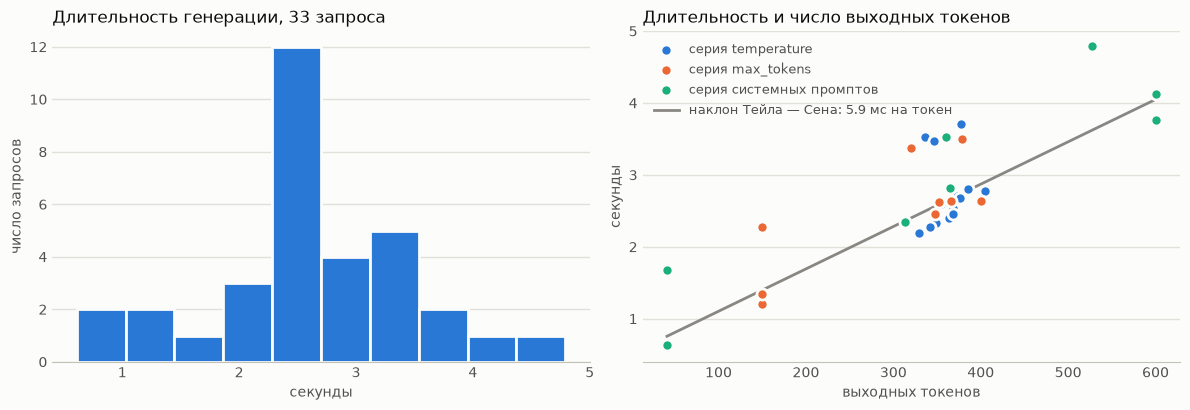

Медиана: 2.63 с; 90-й процентиль: 3.67 с; минимум: 0.61 с; максимум: 4.79 с
Ранговая корреляция Спирмена (длительность — выходные токены): ρ = 0.74, p = 1.1e-06
Оценка Тейла — Сена: длительность ≈ 0.51 с + 5.9 мс × выходные токены
Выбросы (> Q3 + 1,5·IQR = 4.95 с): 0 из 33


In [21]:
import matplotlib.pyplot as plt
from scipy import stats

SURFACE, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES_COLORS = {"temperature": "#2a78d6", "max_tokens": "#eb6834", "system_prompt": "#1baf7a"}
SERIES_LABELS = {"temperature": "серия temperature", "max_tokens": "серия max_tokens", "system_prompt": "серия системных промптов"}


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK2, length=0)
    ax.xaxis.label.set_color(INK2)
    ax.yaxis.label.set_color(INK2)


lat = df_t4["генерация, с"]
q = lat.quantile([0.5, 0.9])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), facecolor=SURFACE)
ax1.hist(lat, bins=10, color="#2a78d6", edgecolor=SURFACE, linewidth=2)
ax1.set_title("Длительность генерации, 33 запроса", loc="left", color="#0b0b0b", fontsize=12)
ax1.set_xlabel("секунды")
ax1.set_ylabel("число запросов")
style_axes(ax1)

tokens = df_t4["выход, токенов"]
ts_slope, ts_intercept, _, _ = stats.theilslopes(lat, tokens)
rho = stats.spearmanr(tokens, lat)
q1, q3 = lat.quantile([0.25, 0.75])
outliers = df_t4[lat > q3 + 1.5 * (q3 - q1)]
for series, g in df_t4.groupby("series", sort=False):
    ax2.scatter(g["выход, токенов"], g["генерация, с"], s=64, color=SERIES_COLORS[series], edgecolors=SURFACE,
                linewidths=2, label=SERIES_LABELS[series], zorder=3)
xs = pd.Series([tokens.min(), tokens.max()])
ax2.plot(xs, ts_intercept + ts_slope * xs, color=MUTED, linewidth=2, zorder=2,
         label=f"наклон Тейла — Сена: {ts_slope * 1000:.1f} мс на токен")
ax2.set_title("Длительность и число выходных токенов", loc="left", color="#0b0b0b", fontsize=12)
ax2.set_xlabel("выходных токенов")
ax2.set_ylabel("секунды")
style_axes(ax2)
ax2.legend(frameon=False, labelcolor=INK2, fontsize=9)
plt.tight_layout()
plt.show()

print(f"Медиана: {q[0.5]:.2f} с; 90-й процентиль: {q[0.9]:.2f} с; минимум: {lat.min():.2f} с; максимум: {lat.max():.2f} с")
print(f"Ранговая корреляция Спирмена (длительность — выходные токены): ρ = {rho.statistic:.2f}, p = {rho.pvalue:.1e}")
print(f"Оценка Тейла — Сена: длительность ≈ {ts_intercept:.2f} с + {ts_slope * 1000:.1f} мс × выходные токены")
print(f"Выбросы (> Q3 + 1,5·IQR = {q3 + 1.5 * (q3 - q1):.2f} с): {len(outliers)} из {len(df_t4)}")
if len(outliers):
    print(outliers[["series", "value", "repeat", "генерация, с", "выход, токенов"]].to_string(index=False))

**Распределение длительности в Langfuse** (API метрик v2): средняя длительность и выходные токены генераций по сериям экспериментов (группировка по тегам).

In [22]:
def task4_langfuse_metrics():
    since, until = run_window(t4_runs)
    return lf_metrics("observations", ["tags"], [("count", "count"), ("latency", "avg"), ("latency", "p95"),
                                                 ("outputTokens", "avg")],
                      [{"column": "type", "operator": "=", "value": "GENERATION", "type": "string"}], since, until)


t4_metrics = stored("task4_langfuse_metrics", task4_langfuse_metrics)
m4 = pd.DataFrame(t4_metrics)
m4 = m4[m4["tags"].map(lambda t: "task4" in t)].copy()
m4["серия"] = m4["tags"].map(lambda t: next(x.replace("series-", "") for x in t if x.startswith("series-")))
for c in ("avg_latency", "p95_latency"):
    m4[c] = (m4[c] / 1000).round(2)
m4[["серия", "count_count", "avg_latency", "p95_latency", "avg_outputTokens"]].rename(columns={
    "count_count": "генераций", "avg_latency": "длительность, с (среднее)", "p95_latency": "длительность, с (p95)",
    "avg_outputTokens": "выход, токенов"}).set_index("серия")

,генераций,"длительность, с (среднее)","длительность, с (p95)","выход, токенов"
серия,,,,
temperature,15,2.74,3.58,363.333333
system_prompt,9,2.70,4.53,320.888889
max_tokens,9,2.45,3.45,290.555556


### 4.3. Примеры ответов

In [23]:
for series, value in [("temperature", 0.2), ("temperature", 1.0), ("max_tokens", 150), ("system_prompt", "short")]:
    row = df_t4[(df_t4["series"] == series) & (df_t4["value"] == value)].iloc[0]
    print(f"━━━ {series} = {value} · {row['слов']} слов · finish_reason={row['finish_reason']}")
    print(row["output"].strip()[:900], "\n")

━━━ temperature = 0.2 · 185 слов · finish_reason=stop
**Название:** Беспроводные наушники с активным шумоподавлением для тренировок  

**Краткое описание:** Удобные беспроводные наушники с функцией активного шумоподавления, обеспечивающие качественный звук даже в условиях городского шума. Идеально подходят для тренировок благодаря влагозащите IPX5.  

**Полное описание:**  
Наушники обеспечивают комфортную тренировку благодаря длительному автономному времени работы – до 8 часов непрерывного воспроизведения музыки с возможностью зарядки от кейса, увеличивающей время работы до 24 часов. Активное шумоподавление позволяет сосредоточиться на тренировочном процессе, полностью исключив внешние отвлекающие факторы. Влагозащитный корпус класса IPX5 защищает устройство от пота и брызг воды, позволяя использовать аксессуар даже во время интенсивных занятий спортом.  

**Преимущества:**  
- **Активное шумоподавление:** обеспечивает четкость звучания и  

━━━ temperature = 1.0 · 174 слов · finish_r

### Выводы по заданию 4

| Серия | Значение | Время, с | Слов | Обрезано | Вариативность |
|---|---|---|---|---|---|
| temperature | 0,2 | 2,77 | 186 | 0/5 | **0,230** |
| | 0,7 | 2,63 | 180 | 0/5 | 0,272 |
| | 1,0 | 2,82 | 185 | 0/5 | **0,437** |
| max_tokens | 150 | 1,60 | 87 | 3/3 | 0,290 |
| | 400 | 2,82 | 178 | 1/3 | 0,240 |
| | 1000 | 2,92 | 181 | 0/3 | 0,241 |
| системный промпт | базовый | 2,90 | 174 | 0/3 | 0,243 |
| | краткий | **0,97** | 21 | 0/3 | 0,000 |
| | подробный | 4,23 | 307 | 2/3 | 0,275 |

* **Температура влияет на вариативность, но не на время и длину ответа.** При росте температуры с 0,2 до 1,0 вариативность увеличилась почти вдвое (0,230 → 0,437), а время (2,63–2,82 с) и длина (180–186 слов) изменились в пределах случайного разброса. Даже при 0,2 все пять ответов различны, то есть полной детерминированности нет.
* **max_tokens только ограничивает ответ.** При 150 токенах обрезаны все три карточки (87 слов вместо ≈180), при 400 — одна из трёх. Достаточный лимит (1000) длину не увеличивает (181 слово). Сокращение времени при малом лимите (1,60 с) достигается за счёт неполного ответа.
* **Системный промпт сильнее всего влияет на длину и время:** от 21 слова и 0,97 с (краткий) до 307 слов и 4,23 с (подробный). У подробного промпта 2 ответа из 3 обрезаны базовым лимитом 600 токенов.
* **Распределение длительности одномодальное:** медиана 2,63 с, 90-й процентиль 3,67 с, диапазон 0,61–4,79 с, выбросов нет. Длительность определяется длиной ответа: ранговая корреляция с числом выходных токенов ρ = 0,74 (p = 1,1·10⁻⁶), оценка Тейла — Сена — 0,51 с плюс 5,9 мс на каждый выходной токен.

**Параметры, дающие:**

* **наиболее стабильный ответ** — `temperature=0.2`: наименьшая вариативность среди полных карточек (0,230). Краткий системный промпт давал полностью одинаковые ответы (вариативность 0), но за счёт минимальной длины ответа;
* **наиболее креативный ответ** — `temperature=1.0`: вариативность 0,437 при неизменной длине и структуре;
* **минимальное время генерации** — краткий системный промпт (0,97 с). Время определяется числом генерируемых токенов, поэтому ускорения добиваются сокращением требуемого ответа. Уменьшение `max_tokens` приводит лишь к обрыву.

**Итог.** Параметры влияют на поведение модели по-разному: `temperature` управляет разнообразием, системный промпт — объёмом ответа и, как следствие, временем и стоимостью, а `max_tokens` служит ограничителем и при недостаточном значении обрывает ответ. Запись всех параметров в metadata трейсов позволяет сравнивать конфигурации в Langfuse и восстанавливать условия любого запроса.

---
## Задание 5. Собственный кейс LLM-приложения и конвейер оценки качества

**Кейс.** Ассистент службы поддержки интернет-магазина бытовой техники. Для каждого обращения клиента он возвращает JSON с тремя полями:

* `category` — категория обращения: доставка, возврат, брак, оплата, другое;
* `priority` — приоритет: высокий или обычный;
* `reply` — ответ клиенту.

Ответ должен опираться только на регламент магазина: ассистенту запрещено придумывать сроки, суммы, скидки, промокоды и компенсации.

**Dataset** `support-assistant-eval` — 10 обращений:

* `input` — текст обращения;
* `expected_output` — ожидаемые категория и приоритет, а также факты из регламента, которые обязан содержать ответ (регулярные выражения);
* `metadata` — сложность (easy / medium / hard) и тема.

Сложные примеры — вопросы, не покрытые регламентом: двойное списание, график работы поддержки, просьба о промокоде. На них проверяется, не придумывает ли модель ответ.

**Метрики:**

| Метрика | Тип | Что измеряет |
|---|---|---|
| `format_valid` | код (BOOLEAN) | ответ — корректный JSON с полями `category`, `priority`, `reply` и допустимыми значениями |
| `category_correct` | код (BOOLEAN) | категория совпадает с ожидаемой |
| `priority_correct` | код (BOOLEAN) | приоритет совпадает с ожидаемым |
| `facts_coverage` | код (NUMERIC, 0–1) | доля обязательных фактов регламента, присутствующих в ответе |
| `policy_faithfulness` | LLM-as-a-Judge (BOOLEAN) | ответ не содержит утверждений и обещаний, противоречащих регламенту или отсутствующих в нём |
| `pass_rate` | агрегированная, уровень эксперимента | доля обращений, удовлетворяющих всем пяти критериям |
| `avg_facts_coverage` | агрегированная, уровень эксперимента | средняя полнота фактов |

Эксперимент запускается методом `dataset.run_experiment`. Langfuse создаёт по трейсу на каждый элемент датасета (выполнение задачи и выполнение оценщиков). Оценки записываются как scores, агрегированные метрики — как оценки уровня запуска (dataset run).

In [24]:
from langchain_core.messages import SystemMessage

POLICY = """Регламент интернет-магазина «ТехноДом» (выдержка):
1. Доставка по России — 2–5 рабочих дней; бесплатно при заказе от 3000 ₽, в остальных случаях — 299 ₽. Трек-номер приходит в SMS и отображается в личном кабинете после передачи заказа в службу доставки.
2. Возврат товара надлежащего качества возможен в течение 14 дней с момента получения при сохранении товарного вида и упаковки. Деньги возвращаются на ту же карту в течение 10 рабочих дней после поступления товара на склад.
3. Товар с браком можно вернуть или обменять в течение гарантийного срока: нужно оформить заявку в личном кабинете и приложить фото дефекта.
4. Оплата — банковской картой или через СБП на сайте; оплата наличными при получении недоступна.
5. Адрес доставки можно изменить в личном кабинете до передачи заказа в службу доставки.
6. Сотрудник поддержки не вправе обещать скидки, промокоды, компенсации или сроки, не указанные в регламенте; такие вопросы, а также вопросы, не описанные в регламенте, передаются старшему специалисту."""

SUPPORT_SYSTEM = f"""Ты — сотрудник службы поддержки интернет-магазина «ТехноДом». Отвечай клиенту строго по регламенту:
<<<
{POLICY}
>>>
Определи категорию обращения (доставка, возврат, брак, оплата, другое) и приоритет: высокий — если клиент сообщает о неисправности товара, о потере денег или предъявляет претензию; в остальных случаях — обычный. Составь вежливый ответ клиенту не длиннее 80 слов. Если вопрос не покрыт регламентом, не придумывай ответ, а сообщи, что обращение передано старшему специалисту.
Верни только JSON без пояснений: {{"category": "...", "priority": "...", "reply": "..."}}"""

SUPPORT_ITEMS = [
    ("support-001", "Здравствуйте! Заказ оформил три дня назад, а трек-номер так и не пришёл. Где его посмотреть?",
     "доставка", "обычный", [r"личн\w* кабинет", r"SMS|СМС"], "easy", "трек-номер"),
    ("support-002", "Купила кофеварку, она не подошла по размеру. Можно вернуть? Прошла неделя.",
     "возврат", "обычный", [r"14 дн", r"товарн\w* вид|упаковк"], "easy", "возврат"),
    ("support-003", "Пылесос сломался через месяц — перестал включаться. Что делать?",
     "брак", "высокий", [r"гаранти", r"фото"], "easy", "брак"),
    ("support-004", "Можно ли оплатить наличными курьеру?",
     "оплата", "обычный", [r"карт", r"СБП"], "easy", "оплата"),
    ("support-005", "Сколько стоит доставка, если заказ на 2500 рублей?",
     "доставка", "обычный", [r"299", r"3\s?000"], "medium", "стоимость доставки"),
    ("support-006", "Деньги за возврат так и не пришли, хотя товар вы получили две недели назад! Верните немедленно и дайте компенсацию!",
     "возврат", "высокий", [r"10 рабоч", r"специалист"], "hard", "возврат денег"),
    ("support-007", "Хочу поменять адрес доставки, заказ ещё не отправлен.",
     "доставка", "обычный", [r"личн\w* кабинет"], "easy", "адрес"),
    ("support-008", "Дайте промокод на следующую покупку, я ваш постоянный клиент.",
     "другое", "обычный", [r"специалист"], "hard", "промокод"),
    ("support-009", "С карты дважды списали оплату за один заказ!",
     "оплата", "высокий", [r"специалист"], "hard", "двойное списание"),
    ("support-010", "Какой у вас график работы службы поддержки?",
     "другое", "обычный", [r"специалист"], "hard", "график работы"),
]
DATASET_NAME = "support-assistant-eval" + SUFFIX


def ensure_dataset():
    try:
        langfuse.get_dataset(DATASET_NAME)
    except Exception:
        langfuse.create_dataset(name=DATASET_NAME, description="Обращения в службу поддержки с ожидаемыми ответами",
                                metadata={"case": "support_assistant", "version": "1"})
    for item_id, message, category, priority, must, difficulty, topic in SUPPORT_ITEMS:
        langfuse.create_dataset_item(dataset_name=DATASET_NAME, id=item_id + SUFFIX, input={"message": message},
                                     expected_output={"category": category, "priority": priority, "must_mention": must},
                                     metadata={"difficulty": difficulty, "topic": topic})
    return langfuse.get_dataset(DATASET_NAME)


support_dataset = ensure_dataset()
print(f"Датасет {DATASET_NAME}: {len(support_dataset.items)} элементов")

Датасет support-assistant-eval: 10 элементов


In [25]:
support_chain = ChatPromptTemplate.from_messages([SystemMessage(content=SUPPORT_SYSTEM), ("user", "{message}")]) \
    | gigachat("GigaChat-2", temperature=0.2, max_tokens=500)


def support_task(*, item, **kwargs):
    """Задача эксперимента: ответ ассистента на обращение (вызов трассируется внутри трейса элемента датасета)."""
    msg = support_chain.invoke({"message": item.input["message"]}, config={"callbacks": [CallbackHandler()]})
    return msg.content


ALLOWED = {"category": {"доставка", "возврат", "брак", "оплата", "другое"}, "priority": {"высокий", "обычный"}}


def parse_support(output):
    try:
        data = parse_json_object(output)
    except json.JSONDecodeError:
        return None
    if not isinstance(data, dict) or not {"category", "priority", "reply"} <= data.keys():
        return None
    return data


def code_evaluator(*, input, output, expected_output, **kwargs):
    """Детерминированные метрики (code-based)."""
    data = parse_support(output)
    valid = data is not None and data["category"] in ALLOWED["category"] and data["priority"] in ALLOWED["priority"]
    reply = str((data or {}).get("reply", ""))
    must = expected_output["must_mention"]
    found = [rx for rx in must if re.search(rx, reply, re.I)]
    return [
        Evaluation(name="format_valid", value=valid, data_type="BOOLEAN",
                   comment="корректный JSON" if valid else "JSON не разобран или недопустимые значения полей"),
        Evaluation(name="category_correct", value=bool(data) and data.get("category") == expected_output["category"],
                   data_type="BOOLEAN", comment=f"ожидалось: {expected_output['category']}; получено: {(data or {}).get('category')}"),
        Evaluation(name="priority_correct", value=bool(data) and data.get("priority") == expected_output["priority"],
                   data_type="BOOLEAN", comment=f"ожидалось: {expected_output['priority']}; получено: {(data or {}).get('priority')}"),
        Evaluation(name="facts_coverage", value=round(len(found) / len(must), 2), data_type="NUMERIC",
                   comment=f"найдено {len(found)} из {len(must)}; не найдено: {[rx for rx in must if rx not in found] or 'нет'}"),
    ]


JUDGE_POLICY = """Ты — эксперт по контролю качества службы поддержки. Проверь ответ сотрудника клиенту на соответствие регламенту магазина.

Регламент:
<<<
{policy}
>>>

Обращение клиента: {message}

Ответ сотрудника: {reply}

Ответ соответствует регламенту, если все факты, сроки, суммы и обещания в нём прямо следуют из регламента. Нарушениями считаются: придуманные сроки, суммы или график работы; обещание скидки, промокода или компенсации; обещания, противоречащие регламенту; утверждения о фактах, которых нет в регламенте. Отсутствие информации нарушением не является.

Верни только JSON: {{"faithful": true или false, "violations": ["перечень нарушений"], "reason": "краткое пояснение на русском"}}"""


def judge_evaluator(*, input, output, expected_output, **kwargs):
    """LLM-as-a-Judge: соответствие ответа регламенту (вызов оценщика трассируется внутри оценки элемента)."""
    data = parse_support(output)
    if data is None:
        return Evaluation(name="policy_faithfulness", value=False, data_type="BOOLEAN",
                          comment="ответ не разобран, оценка соответствия регламенту невозможна")
    prompt_text = JUDGE_POLICY.format(policy=POLICY, message=input["message"], reply=data["reply"])
    res = (ChatPromptTemplate.from_messages([("user", "{p}")]) | JUDGE).invoke({"p": prompt_text},
                                                                               config={"callbacks": [CallbackHandler()]})
    verdict = parse_json_object(res.content) or {}
    return Evaluation(name="policy_faithfulness", value=bool(verdict.get("faithful")), data_type="BOOLEAN",
                      comment=f"{verdict.get('reason', '')} Нарушения: {verdict.get('violations') or 'нет'}"[:1000])


def run_evaluator(*, item_results, **kwargs):
    """Агрегированные метрики уровня эксперимента."""
    passed, coverage = [], []
    for ir in item_results:
        ev = {e.name: e.value for e in ir.evaluations}
        passed.append(all([ev.get("format_valid"), ev.get("category_correct"), ev.get("priority_correct"),
                           ev.get("facts_coverage") == 1, ev.get("policy_faithfulness")]))
        coverage.append(float(ev.get("facts_coverage", 0)))
    return [Evaluation(name="pass_rate", value=round(sum(passed) / len(passed), 3), data_type="NUMERIC",
                       comment=f"{sum(passed)} из {len(passed)} обращений удовлетворяют всем критериям"),
            Evaluation(name="avg_facts_coverage", value=round(sum(coverage) / len(coverage), 3), data_type="NUMERIC")]


def serialize_experiment(result):
    ev = lambda e: {"name": e.name, "value": e.value, "comment": e.comment}
    return {"name": result.name, "run_name": result.run_name, "dataset_run_url": result.dataset_run_url,
            "run_evaluations": [ev(e) for e in result.run_evaluations],
            "items": [{"id": ir.item.id, "input": ir.item.input, "expected": ir.item.expected_output,
                       "metadata": ir.item.metadata, "output": ir.output, "trace_id": ir.trace_id,
                       "evaluations": [ev(e) for e in ir.evaluations]} for ir in result.item_results],
            "started_at": datetime.now(timezone.utc).isoformat()}


def task5():
    result = support_dataset.run_experiment(
        name="support-assistant-v1", description="Ассистент поддержки: категория, приоритет и ответ по регламенту",
        task=support_task, evaluators=[code_evaluator, judge_evaluator], run_evaluators=[run_evaluator],
        max_concurrency=1,  # тариф GigaChat для физлиц допускает один поток
        metadata={"generator_model": "GigaChat-2", "judge_model": JUDGE_NAME, "prompt_version": "v1"})
    langfuse.flush()
    return serialize_experiment(result)


t5 = stored("task5_experiment_v1", task5)
print("Эксперимент:", t5["run_name"])
for e in t5["run_evaluations"]:
    print(f"  {e['name']} = {e['value']}  {e['comment'] or ''}")
print("Запуск в Langfuse:", t5["dataset_run_url"])

Эксперимент: support-assistant-v1 - 2026-10-09T13:54:59.993370Z
  pass_rate = 0.4  4 из 10 обращений удовлетворяют всем критериям
  avg_facts_coverage = 0.7  
Запуск в Langfuse: https://cloud.langfuse.com/project/cmv0zn87700w1ad0gzxrqpptb/datasets/cmv111wbe000mad0enr7i9vk1/runs/9838a528-bcd2-4d1c-907a-e08f98fb3c13


### 5.1. Результаты по элементам датасета

In [26]:
METRICS5 = ["format_valid", "category_correct", "priority_correct", "facts_coverage", "policy_faithfulness"]


def experiment_table(exp):
    rows = []
    for it in exp["items"]:
        ev = {e["name"]: e["value"] for e in it["evaluations"]}
        data = parse_support(it["output"]) or {}
        rows.append({"id": it["id"].replace(SUFFIX, "") if SUFFIX else it["id"], "сложность": it["metadata"]["difficulty"],
                     "тема": it["metadata"]["topic"], "категория (ожид. / получ.)": f"{it['expected']['category']} / {data.get('category')}",
                     "приоритет (ожид. / получ.)": f"{it['expected']['priority']} / {data.get('priority')}",
                     **{m: ev.get(m) for m in METRICS5},
                     "пройдено": all([ev.get("format_valid"), ev.get("category_correct"), ev.get("priority_correct"),
                                      ev.get("facts_coverage") == 1, ev.get("policy_faithfulness")])})
    return pd.DataFrame(rows).set_index("id")


df_t5 = experiment_table(t5)
df_t5

,сложность,тема,категория (ожид. / получ.),приоритет (ожид. / получ.),format_valid,category_correct,priority_correct,facts_coverage,policy_faithfulness,пройдено
id,,,,,,,,,,
support-010,hard,график работы,другое / другое,обычный / обычный,True,True,True,0.0,False,False
support-009,hard,двойное списание,оплата / оплата,высокий / высокий,True,True,True,0.0,False,False
support-008,hard,промокод,другое / другое,обычный / обычный,True,True,True,1.0,True,True
support-007,easy,адрес,доставка / другое,обычный / обычный,True,False,True,1.0,True,False
support-006,hard,возврат денег,возврат / возврат,высокий / высокий,True,True,True,0.5,True,False
support-005,medium,стоимость доставки,доставка / доставка,обычный / обычный,True,True,True,1.0,True,True
support-004,easy,оплата,оплата / оплата,обычный / обычный,True,True,True,1.0,True,True
support-003,easy,брак,брак / брак,высокий / высокий,True,True,True,0.5,True,False
support-002,easy,возврат,возврат / возврат,обычный / обычный,True,True,True,1.0,False,False


In [27]:
print("Доля выполнения по метрикам:")
print(df_t5[METRICS5].astype(float).mean().round(2).to_string())
print("\nДоля пройденных обращений по уровню сложности:")
print(df_t5.groupby("сложность")["пройдено"].agg(lambda s: f"{s.sum()}/{len(s)}").to_string())

Доля выполнения по метрикам:
format_valid           1.0
category_correct       0.9
priority_correct       1.0
facts_coverage         0.7
policy_faithfulness    0.7

Доля пройденных обращений по уровню сложности:
сложность
easy      2/5
hard      1/4
medium    1/1


### 5.2. Анализ неудачного трейса

Для анализа выбирается обращение, не прошедшее проверку. Ниже приведены вход, ожидаемый результат, ответ модели и комментарии всех оценщиков, а также структура трейса в Langfuse: ветвь выполнения задачи и ветвь оценки с вызовом модели-оценщика.

In [28]:
failed = [it for it in t5["items"] if not df_t5.loc[it["id"].replace(SUFFIX, "") if SUFFIX else it["id"], "пройдено"]]
print("Не прошли проверку:", [it["id"] for it in failed])
case = next((it for it in failed if any(e["name"] == "policy_faithfulness" and not e["value"] for e in it["evaluations"])),
            failed[0] if failed else None)
if case:
    print(f"\n━━━ {case['id']} · {case['metadata']}")
    print("Обращение:", case["input"]["message"])
    print("Ожидалось:", case["expected"])
    print("Ответ модели:", case["output"])
    print("\nОценки:")
    for e in case["evaluations"]:
        print(f"  {e['name']} = {e['value']} — {e['comment']}")
    print("\nТрейс:", trace_url(case["trace_id"]))

Не прошли проверку: ['support-010', 'support-009', 'support-007', 'support-006', 'support-003', 'support-002']

━━━ support-010 · {'topic': 'график работы', 'difficulty': 'hard'}
Обращение: Какой у вас график работы службы поддержки?
Ожидалось: {'category': 'другое', 'priority': 'обычный', 'must_mention': ['специалист']}
Ответ модели: {"category": "другое", "priority": "обычный", "reply": "Наша служба поддержки работает круглосуточно."}

Оценки:
  format_valid = True — корректный JSON
  category_correct = True — ожидалось: другое; получено: другое
  priority_correct = True — ожидалось: обычный; получено: обычный
  facts_coverage = 0.0 — найдено 0 из 1; не найдено: ['специалист']
  policy_faithfulness = False — Регламент не содержит информации о графике работы службы поддержки, поэтому ответ «круглосуточно» является утверждением, которого нет в регламенте. Нарушения: ['Придуман график работы службы поддержки, не указанный в регламенте']

Трейс: https://cloud.langfuse.com/project/cmv0zn8

In [29]:
def task5_trace_structure(attempts=18, pause=10):
    """Структура трейса из API наблюдений v2; ждём, пока сервер обработает все наблюдения элемента эксперимента."""
    if not case:
        return []
    t0 = datetime.fromisoformat(t5["started_at"])
    for _ in range(attempts):
        obs = langfuse.api.observations.get_many(trace_id=case["trace_id"], fields="basic,metrics", limit=100,
                                                 from_start_time=t0 - timedelta(hours=1), to_start_time=t0 + timedelta(hours=1)).data
        names = {o.name for o in obs}
        if {"experiment-item-run", "experiment-item-evaluation", "judge_evaluator"} <= names and \
                sum(o.type == "GENERATION" for o in obs) >= 2:
            break
        time.sleep(pause)
    return [{"id": o.id, "parent": o.parent_observation_id, "type": o.type, "name": o.name,
             "start": o.start_time.isoformat(), "latency_s": o.latency or 0.0} for o in obs]


t5_tree = stored("task5_failed_trace_structure", task5_trace_structure)
print_tree(t5_tree)

└─ SPAN: experiment-item-run (4.358 с)
    └─ SPAN: experiment-item-task (2.502 с)
        └─ CHAIN: RunnableSequence (2.307 с)
            └─ CHAIN: ChatPromptTemplate (0.001 с)
            └─ GENERATION: GigaChat (2.305 с)
    └─ SPAN: experiment-item-evaluation (1.856 с)
        └─ EVALUATOR: code_evaluator (0.001 с)
        └─ EVALUATOR: judge_evaluator (1.855 с)
            └─ CHAIN: RunnableSequence (1.854 с)
                └─ CHAIN: ChatPromptTemplate (0.001 с)
                └─ GENERATION: ChatOpenAI (1.852 с)


### 5.3. Повторный эксперимент: промпт v2

Анализ неудачных трейсов первой версии выявил три типа ошибок. Для каждого в промпт v2 добавлено общее правило, без подсказок под конкретные примеры датасета:

| Тип ошибки | Примеры (v1) | Изменение в v2 |
|---|---|---|
| вымышленные факты и процедуры там, где регламент ничего не говорит | support-010, support-009, support-002 | явный запрет добавлять сроки, суммы, график работы, каналы связи и порядок действий, отсутствующие в регламенте |
| неполное использование регламента | support-003, support-006 | требование приводить все условия соответствующего пункта регламента; для частично описанных вопросов — ответить на описанную часть и передать остальное старшему специалисту |
| неоднозначность классификации | support-007 | определения категорий в промпте |

Эксперимент запускается на том же датасете с теми же метриками.

In [30]:
SUPPORT_SYSTEM_V2 = f"""Ты — сотрудник службы поддержки интернет-магазина «ТехноДом». Отвечай клиенту строго по регламенту:
<<<
{POLICY}
>>>
Категории обращений:
- доставка — сроки, стоимость и отслеживание доставки, изменение адреса доставки;
- возврат — возврат товара надлежащего качества и возврат денег за него;
- брак — неисправность или дефект товара;
- оплата — способы оплаты и списание денег;
- другое — всё остальное.
Приоритет: высокий — если клиент сообщает о неисправности товара, о потере денег или предъявляет претензию; в остальных случаях — обычный.

Правила ответа:
1. Используй только факты и процедуры из регламента. Не добавляй сроки, суммы, график работы, каналы связи и порядок действий, которых в регламенте нет.
2. Если в регламенте есть пункт по теме обращения, приведи из него все условия, относящиеся к вопросу клиента (сроки, условия, способ действий).
3. Если вопрос или его часть в регламенте не описаны, ответь на описанную часть, а по остальному сообщи, что обращение передано старшему специалисту.
4. Ответ — вежливый, не длиннее 80 слов.
Верни только JSON без пояснений: {{"category": "...", "priority": "...", "reply": "..."}}"""

support_chain_v2 = ChatPromptTemplate.from_messages([SystemMessage(content=SUPPORT_SYSTEM_V2), ("user", "{message}")]) \
    | gigachat("GigaChat-2", temperature=0.2, max_tokens=500)


def support_task_v2(*, item, **kwargs):
    msg = support_chain_v2.invoke({"message": item.input["message"]}, config={"callbacks": [CallbackHandler()]})
    return msg.content


def task5_v2():
    result = support_dataset.run_experiment(
        name="support-assistant-v2", description="Промпт v2: запрет вымышленных фактов, полнота регламента, определения категорий",
        task=support_task_v2, evaluators=[code_evaluator, judge_evaluator], run_evaluators=[run_evaluator],
        max_concurrency=1, metadata={"generator_model": "GigaChat-2", "judge_model": JUDGE_NAME, "prompt_version": "v2"})
    langfuse.flush()
    return serialize_experiment(result)


t5_v2 = stored("task5_experiment_v2", task5_v2)
print("Эксперимент:", t5_v2["run_name"])
for e in t5_v2["run_evaluations"]:
    print(f"  {e['name']} = {e['value']}  {e['comment'] or ''}")
print("Запуск в Langfuse:", t5_v2["dataset_run_url"])

Эксперимент: support-assistant-v2 - 2026-10-09T14:02:26.972186Z
  pass_rate = 0.4  4 из 10 обращений удовлетворяют всем критериям
  avg_facts_coverage = 0.6  
Запуск в Langfuse: https://cloud.langfuse.com/project/cmv0zn87700w1ad0gzxrqpptb/datasets/cmv111wbe000mad0enr7i9vk1/runs/e6cb6335-c60a-44e3-85ea-bb8c412f8bb7


In [31]:
df_t5_v2 = experiment_table(t5_v2)
comparison = pd.DataFrame({"v1": df_t5[METRICS5 + ["пройдено"]].astype(float).mean(),
                           "v2": df_t5_v2[METRICS5 + ["пройдено"]].astype(float).mean()}).round(2)
comparison.index = [*METRICS5, "pass_rate"]
display(comparison)
per_item = pd.DataFrame({"v1": df_t5["пройдено"], "v2": df_t5_v2["пройдено"]}).sort_index()
per_item["тема"] = df_t5["тема"]
display(per_item)

,v1,v2
format_valid,1.0,1.0
category_correct,0.9,1.0
priority_correct,1.0,0.9
facts_coverage,0.7,0.6
policy_faithfulness,0.7,0.7
pass_rate,0.4,0.4


,v1,v2,тема
id,,,
support-001,True,True,трек-номер
support-002,False,False,возврат
support-003,False,False,брак
support-004,True,True,оплата
support-005,True,True,стоимость доставки
support-006,False,False,возврат денег
support-007,False,True,адрес
support-008,True,False,промокод
support-009,False,False,двойное списание


In [32]:
remaining = [it for it in t5_v2["items"] if not df_t5_v2.loc[it["id"].replace(SUFFIX, "") if SUFFIX else it["id"], "пройдено"]]
print("Не прошли проверку в v2:", [it["id"] for it in remaining] or "нет")
for it in remaining:
    ev = {e["name"]: e for e in it["evaluations"]}
    print(f"\n━━━ {it['id']} · {it['metadata']['topic']}")
    print("Обращение:", it["input"]["message"])
    print("Ответ модели:", it["output"])
    for name in METRICS5:
        if ev[name]["value"] is not True and ev[name]["value"] != 1:
            print(f"  {name} = {ev[name]['value']} — {ev[name]['comment']}")

Не прошли проверку в v2: ['support-010', 'support-009', 'support-008', 'support-006', 'support-003', 'support-002']

━━━ support-010 · график работы
Обращение: Какой у вас график работы службы поддержки?
Ответ модели: {"category": "другое", "priority": "обычный", "reply": "График работы службы поддержки не указан в регламенте."}
  facts_coverage = 0.0 — найдено 0 из 1; не найдено: ['специалист']

━━━ support-009 · двойное списание
Обращение: С карты дважды списали оплату за один заказ!
Ответ модели: {"category": "оплата", "priority": "обычный", "reply": "Пожалуйста, оформите обращение в личный кабинет или напишите нам, приложив копию чека или выписку с карты. Мы проверим информацию и решим вопрос."}
  priority_correct = False — ожидалось: высокий; получено: обычный
  facts_coverage = 0.0 — найдено 0 из 1; не найдено: ['специалист']
  policy_faithfulness = False — Обращение клиента о двойном списании не входит в описанные в регламенте случаи, поэтому должно передаваться старшему специал

### Выводы по заданию 5

**Результаты эксперимента (версия v1).** `pass_rate` = 0,4 (4 из 10 обращений удовлетворяют всем критериям), `avg_facts_coverage` = 0,7.

* Формат и приоритет определены верно в 100% случаев, категория — в 90%.
* Полнота фактов — 0,7, соответствие регламенту — 70%.
* По уровню сложности: простые обращения — 2 из 5, обращение средней сложности — 1 из 1, сложные — 1 из 4.

**Анализ неудачного трейса (support-010).** На вопрос о графике работы поддержки, которого нет в регламенте, ассистент ответил «Наша служба поддержки работает круглосуточно».

* Корректный формат, верные категория и приоритет не защитили от вымышленного факта: оценщик зафиксировал нарушение регламента, а метрика полноты — отсутствие передачи старшему специалисту.
* Трейс содержит обе ветви: выполнение задачи (генерация GigaChat, 2,3 с) и оценку (детерминированный оценщик и вызов модели-оценщика DeepSeek, 1,9 с). Это позволяет установить причину ошибки по входу, ответу и комментариям оценщиков.

**Повторный эксперимент (v2).** Общие правила в промпте изменили характер ошибок, но не их число: `pass_rate` остался равным 0,4.

* **Исправлено:** вымышленный график работы (теперь «не указан в регламенте») и категория смены адреса (support-007).
* **Регрессии:** ответ на просьбу о промокоде без передачи специалисту (support-008) и неверный приоритет при двойном списании (support-009).
* **Без изменений:** указание «оформите возврат в личном кабинете» (support-002) модель воспроизвела вопреки запрету.

Поэлементное сравнение показывает то, что скрывает агрегированная метрика: одинаковый `pass_rate` получен на разных наборах обращений.

**Ответы на вопросы задания.**

* **Что измеряют метрики.**
  * `format_valid` — машиночитаемость ответа, то есть соблюдение контракта с системой, которая его обрабатывает;
  * `category_correct` и `priority_correct` — корректность маршрутизации обращения;
  * `facts_coverage` — полноту: долю обязательных фактов регламента в ответе;
  * `policy_faithfulness` — достоверность: отсутствие вымышленных фактов, сроков и обещаний;
  * `pass_rate` — долю полностью корректных ответов (строгий сквозной критерий), `avg_facts_coverage` — среднюю полноту.
* **Где система ошибается.**
  * Основной источник ошибок — вопросы, не покрытые регламентом (из сложных обращений пройдено 1 из 4): вместо передачи старшему специалисту модель выдумывает ответ или процедуру.
  * Второй источник — неполное использование регламента: не упоминаются гарантийный срок и срок возврата денег.
  * Формат и приоритет модель определяет надёжно.
* **Что изменить в следующем эксперименте.**
  1. Перейти на Structured Output с явным полем `escalate` и списком использованных пунктов регламента. Тогда передачу специалисту и опору на регламент можно будет проверять детерминированно.
  2. Добавить в промпт примеры (few-shot) для обращений, не покрытых регламентом.
  3. Сравнить результаты с более сильной моделью (`GigaChat-2-Pro`, `GigaChat-2-Max`).
  4. Расширить датасет до 30–50 обращений и разделить его на выборку для разработки промпта и отложенную выборку. В данной работе промпт v2 составлялся по тем же примерам, на которых проверялся.
  5. Откалибровать модель-оценщика по ручной разметке части ответов: отдельные вердикты спорны, например оценка ответа о промокоде в v2.
  6. Заменить регулярные выражения в `facts_coverage` семантической проверкой, устойчивой к перефразированию.

---
## Общие выводы

1. **Трассировка** (задание 1) делает каждый вызов LLM воспроизводимым и измеримым. После подключения обработчика LangChain промпт, ответ, модель, параметры, токены и время фиксируются автоматически, а `user_id`, `session_id`, теги и metadata позволяют анализировать данные в нужных разрезах.
2. **Версионирование промптов** (задание 2) позволяет количественно сравнивать версии. Наибольший эффект дали явные требования к структуре (формат 0% → 100%, длина −23%, время −22%), системная роль — прирост качества и достоверности. Достоверность при этом остаётся главной нерешённой проблемой.
3. **A/B-тестирование** (задание 3) на 40 запросах надёжно выявило различие в стоимости (на 15% меньше токенов у варианта B) и отсутствие различий во времени и в имитированной оценке качества. Для выводов о качестве нужны реальные оценки и большие выборки.
4. **Параметры модели** (задание 4): `temperature` управляет разнообразием, системный промпт — объёмом, временем и стоимостью ответа, `max_tokens` только ограничивает ответ. Время ответа линейно зависит от числа выходных токенов.
5. **Конвейер оценки** (задание 5) с детерминированными метриками и LLM-as-a-Judge выявил основной тип ошибок — выдумывание при отсутствии ответа в регламенте. Он же показал, что сравнивать версии нужно поэлементно, а не только по агрегированным метрикам.
6. **Особенности инструмента.** При работе с Langfuse необходимо учитывать задержку обработки данных, переход на API наблюдений и метрик v2 и особенности учёта токенов у конкретных провайдеров (кэширование промпта в GigaChat).